In [ ]:
import sys
sys.path.append(r"D:\Train_thử\fairchem-tio2-s2ef")

from ocpmodels.preprocessing import AtomsToGraphs
from ocpmodels.datasets import SinglePointLmdbDataset, TrajectoryLmdbDataset, OC22LmdbDataset, LmdbDataset
import ase.io
from ase.build import bulk
from ase.build import fcc100, add_adsorbate, molecule
from ase.constraints import FixAtoms
from ase.calculators.emt import EMT
from ase.optimize import BFGS
import matplotlib.pyplot as plt
import lmdb
import pickle
from tqdm import tqdm
import torch
import os

In [2]:
# dataset = TrajectoryLmdbDataset({"src": "s2ef/"})
# dataset = OC22LmdbDataset({"src": r"D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\s2ef_total_train_val_test_lmdbs\data\oc22\s2ef-total\val_ood\data.0000.lmdb"})
dataset = LmdbDataset({"src": r"D:\Train_thử\fairchem-tio2-s2ef\tio2_s2ef\oc22_data\tio2_filtered\train"})

len(dataset)

2097

## Draw Three Dimension Of The Data 

In [4]:
import plotly.graph_objects as go
from ase.data import chemical_symbols
import numpy as np

# Select which sid and fid you want to visualize
target_sid = 12032    # ← change this to any sid you want 12032, 1068, 31757, 2714, 23315
target_fid = 50       # ← change this to any fid you want

# Find the matching index in dataset
selected_data = None

for i in range(len(dataset)):
    try:
        d = dataset[i]
        if int(d.sid) == target_sid and int(d.fid) == target_fid:
            selected_data = d
            print(f"Found: index={i} | sid={d.sid} | fid={d.fid}")
            break
    except:
        continue

if selected_data is None:
    print(f"No match found for sid={target_sid}, fid={target_fid}")
else:
    # ── Extract data ──────────────────────────────────────────────
    data = selected_data
    pos  = data.pos.numpy()
    z    = data.atomic_numbers.numpy().astype(int)
    tags = data.tags.numpy().astype(int)

    # ── Plot ──────────────────────────────────────────────────────
    roles  = {0: "bulk atom", 1: "Surface", 2: "Adsorbate"}
    colors = {"bulk atom": "blue", "Surface": "green", "Adsorbate": "red"}

    fig = go.Figure()

    for tag_val, role in roles.items():
        mask = tags == tag_val
        if mask.sum() == 0:
            continue
        pts = pos[mask]
        fig.add_trace(
            go.Scatter3d(
                x=pts[:, 0],
                y=pts[:, 1],
                z=pts[:, 2],
                mode="markers+text",
                marker=dict(size=4, color=colors[role]),
                name=f"{role} ({mask.sum()})",
                text=[chemical_symbols[n] for n in z[mask]],
                textposition="top center",
                hovertemplate=(
                    "atom=%{text}<br>"
                    "x=%{x:.2f}<br>"
                    "y=%{y:.2f}<br>"
                    "z=%{z:.2f}<extra></extra>"
                ),
            )
        )

    fig.update_layout(
        title=f"3D Atoms — sid={data.sid} | fid={data.fid}",
        scene=dict(
            xaxis_title="x (Å)",
            yaxis_title="y (Å)",
            zaxis_title="z (Å)",
            aspectmode="data",
        ),
        width=900,
        height=700,
    )
    fig.show()

Found: index=20 | sid=12032 | fid=50


## Find The Location Of Atoms Relating To Tags

In [3]:
from ase.data import chemical_symbols

# ── Select which sid and fid you want to view ─────────────────────
target_sid = 12032    # ← change this to any sid you want 12032, 1068, 31757, 2714, 23315
target_fid = 50       # ← change this to any fid you want

# ── Search for matching index in dataset ──────────────────────────
selected_data = None

for i in range(len(dataset)):
    try:
        d = dataset[i]
        if int(d.sid) == target_sid and int(d.fid) == target_fid:
            selected_data = d
            print(f"Found: index={i} | sid={d.sid} | fid={d.fid}")
            break
    except:
        continue

if selected_data is None:
    print(f"No match found for sid={target_sid}, fid={target_fid}")
    print(f"Tips:")
    print(f"  - Valid sids : 12032, 1068, 31757, 2714, 23315")
    print(f"  - Valid fids : 0 to 396")

else:
    data      = selected_data
    atom_list = [chemical_symbols[int(z)] for z in data.atomic_numbers]

    print(f"\nElements in this system: {set(atom_list)}")
    print(f"Total atoms            : {len(atom_list)}")
    print()

    # ── Print all atoms with their role and position ───────────────
    print(f"{'Atom':<6} {'Element':<10} {'Role':<12} {'x':>8} {'y':>8} {'z':>8}")
    print("-" * 55)

    for i, symbol in enumerate(atom_list):
        tag  = data.tags[i].item()
        role = (
            "Bulk"     if tag == 0 else
            "Surface"  if tag == 1 else
            "Adsorbate"
        )
        x, y, z = data.pos[i].tolist()
        print(f"{i:<6} {symbol:<10} {role:<12} {x:>8.3f} {y:>8.3f} {z:>8.3f}")

Found: index=20 | sid=12032 | fid=50

Elements in this system: {'O', 'C', 'Ti'}
Total atoms            : 97

Atom   Element    Role                x        y        z
-------------------------------------------------------
0      Ti         Bulk            6.310    0.184   12.677
1      Ti         Bulk           12.754    0.085   12.597
2      Ti         Bulk           12.455    6.111   12.769
3      Ti         Bulk           18.893    6.476   12.541
4      Ti         Bulk           12.800    2.847   13.338
5      Ti         Bulk            6.337    3.030   13.255
6      Ti         Bulk            9.156    3.581   14.378
7      Ti         Bulk           15.627    3.681   14.340
8      Ti         Bulk            7.339    1.250   16.096
9      Ti         Bulk           13.789    1.245   16.084
10     Ti         Bulk           10.781    1.008   14.997
11     Ti         Bulk            4.349    1.038   15.035
12     Ti         Bulk           13.798    4.541   16.764
13     Ti         Bulk 

## The Detailed Infor Of the Closest Distance Of Atoms 

In [4]:
import numpy as np
from ase.data import chemical_symbols

# ── Select which sid and fid you want ────────────────────────────
target_sid = 1068  #← change this to any sid you want 12032, 1068, 31757, 2714, 23315
target_fid = 7

# ── Search dataset ────────────────────────────────────────────────
selected_data = None
for i in range(len(dataset)):
    try:
        d = dataset[i]
        if int(d.sid) == target_sid and int(d.fid) == target_fid:
            selected_data = d
            print(f"Found: index={i} | sid={d.sid} | fid={d.fid}")
            break
    except:
        continue

if selected_data is None:
    print(f"No match found for sid={target_sid}, fid={target_fid}")

else:
    data     = selected_data
    pos      = data.pos.numpy()
    tags     = data.tags.numpy().astype(int)
    nums     = data.atomic_numbers.numpy().astype(int)
    symbols  = [chemical_symbols[n] for n in nums]

    # ── Separate atoms by role ────────────────────────────────────
    bulk_idx    = np.where(tags == 0)[0]
    surface_idx = np.where(tags == 1)[0]
    ads_idx     = np.where(tags == 2)[0]

    print(f"\nAtom counts:")
    print(f"  Bulk     (tag=0): {len(bulk_idx)}")
    print(f"  Surface  (tag=1): {len(surface_idx)}")
    print(f"  Adsorbate(tag=2): {len(ads_idx)}")

    # ── ALL non-adsorbate atoms = potential surface to measure ────
    # Include BOTH bulk (tag=0) and surface (tag=1)
    # So we can see which one the adsorbate is actually closest to
    non_ads_idx = np.where(tags != 2)[0]

    print(f"\n{'='*70}")
    print(f"Distance from each ADSORBATE atom to ALL surface/bulk atoms")
    print(f"{'='*70}")

    rows = []

    for ads_i in ads_idx:
        ads_sym = symbols[ads_i]
        ads_pos = pos[ads_i]

        # Calculate distance to every non-adsorbate atom
        distances_to_all = []
        for surf_i in non_ads_idx:
            dist = np.linalg.norm(pos[surf_i] - ads_pos)
            tag  = tags[surf_i]
            role = "Bulk" if tag == 0 else "Surface"
            distances_to_all.append({
                "atom_idx":  surf_i,
                "symbol":    symbols[surf_i],
                "role":      role,
                "tag":       tag,
                "distance":  dist
            })

        # Sort by distance — closest first
        distances_to_all.sort(key=lambda x: x["distance"])

        # Take top 5 closest atoms
        top5 = distances_to_all[:5]

        # ── Identify adsorption site ──────────────────────────────
        closest      = top5[0]
        closest_sym  = closest["symbol"]
        closest_dist = closest["distance"]

        if closest_sym == "Ti":
            site_on = "Ti site"
        elif closest_sym == "O":
            site_on = "O site"
        else:
            site_on = f"{closest_sym} site"

        # ── Bridge check ──────────────────────────────────────────
        second       = top5[1]
        site_type    = "Top"
        if abs(second["distance"] - closest_dist) <= 0.3:
            site_type = "Bridge"
            site_on   = f"{closest_sym}/{second['symbol']} site"

        # ── Hollow check ──────────────────────────────────────────
        third = top5[2]
        if (abs(second["distance"] - closest_dist) <= 0.3 and
                abs(third["distance"]  - closest_dist) <= 0.3):
            site_type = "Hollow"
            site_on   = (f"{closest_sym}/"
                         f"{second['symbol']}/"
                         f"{third['symbol']} site")

        # ── Print result for this adsorbate atom ──────────────────
        print(f"\nAdsorbate atom: {ads_sym}({ads_i})")
        print(f"  Site type    : {site_type}")
        print(f"  Adsorbed on  : {site_on}")
        print(f"  Top 5 closest atoms:")
        print(f"  {'Rank':<6} {'Atom':<12} {'Role':<10} "
              f"{'Tag':<6} {'Distance (Å)'}")
        print(f"  {'-'*50}")

        for rank, atom in enumerate(top5):
            marker = " ← closest" if rank == 0 else ""
            print(f"  {rank+1:<6} "
                  f"{atom['symbol']}({atom['atom_idx']})  "
                  f"{'':<4}{atom['role']:<10} "
                  f"{atom['tag']:<6} "
                  f"{atom['distance']:.3f} Å{marker}")

        rows.append({
            "Adsorbate":         f"{ads_sym}({ads_i})",
            "Site Type":         site_type,
            "Adsorbed On":       site_on,
            "Closest Atom":      f"{closest['symbol']}({closest['atom_idx']})",
            "Closest Role":      closest["role"],
            "Closest Tag":       closest["tag"],
            "Closest Dist (Å)":  round(closest_dist, 3),
        })

    # ── Summary table ─────────────────────────────────────────────
    import pandas as pd
    df = pd.DataFrame(rows)

    print(f"\n{'='*70}")
    print(f"SUMMARY TABLE")
    print(f"{'='*70}")
    print(df.to_string(index=False))


Found: index=1 | sid=1068 | fid=7

Atom counts:
  Bulk     (tag=0): 77
  Surface  (tag=1): 17
  Adsorbate(tag=2): 6

Distance from each ADSORBATE atom to ALL surface/bulk atoms

Adsorbate atom: H(32)
  Site type    : Bridge
  Adsorbed on  : Ti/Ti site
  Top 5 closest atoms:
  Rank   Atom         Role       Tag    Distance (Å)
  --------------------------------------------------
  1      Ti(31)      Surface    1      2.166 Å ← closest
  2      Ti(28)      Surface    1      2.289 Å
  3      O(90)      Surface    1      2.474 Å
  4      Ti(27)      Bulk       0      4.078 Å
  5      O(88)      Surface    1      4.324 Å

Adsorbate atom: H(33)
  Site type    : Top
  Adsorbed on  : O site
  Top 5 closest atoms:
  Rank   Atom         Role       Tag    Distance (Å)
  --------------------------------------------------
  1      O(97)      Surface    1      0.963 Å ← closest
  2      O(85)      Surface    1      2.400 Å
  3      Ti(25)      Surface    1      2.831 Å
  4      O(99)      Surface   

## Support

In [6]:
import numpy as np
import pandas as pd
from ase.data import chemical_symbols
from scipy.spatial.distance import cdist
target_sids = {"12032", "1068", "31757", "2714", "23315"}
rows = []

# ── Ti5c detection function ───────────────────────────────────────
def find_ti5c_indices(positions, atomic_numbers, tags, cutoff=3.0):
    distances   = cdist(positions, positions)
    oxygen_mask = atomic_numbers == 8
    ti5c_set    = set()

    ti_surface_indices = np.where((atomic_numbers == 22) & (tags == 1))[0]

    for i in ti_surface_indices:
        n_oxygen_neighbors = np.sum(
            (distances[i] <= cutoff) &
            (distances[i] > 0)      &
            oxygen_mask
        )
        if n_oxygen_neighbors == 5:
            ti5c_set.add(i)

    return ti5c_set

## Find And Filter All Results Having Ti(5c) Interaction

In [7]:
# ── Step 1: Build initial surface atom positions (fid=0) ──────────
# Store surface atom positions at fid=0 (before adsorption effect)
# so we can measure how much surface atoms moved after adsorption
initial_surface_positions = {}   # {sid: {atom_index: initial_xyz}}

for idx in range(len(dataset)):
    data = dataset[idx]
    sid  = str(data.sid)
    fid  = int(data.fid)

    if sid not in target_sids:
        continue
    if fid != 0:
        continue    # only collect first frame

    pos  = data.pos.numpy()
    tags = data.tags.numpy().astype(int)

    # Collect surface atoms (tag=1) initial positions
    surf_mask = tags == 1
    if surf_mask.sum() == 0:
        continue

    initial_surface_positions[sid] = {}
    for surf_local_index in np.where(surf_mask)[0]:
        initial_surface_positions[sid][surf_local_index] = (
            pos[surf_local_index].copy()
        )

print(f"Initial surface positions collected for sids: "
      f"{list(initial_surface_positions.keys())}")
# ── Step 2: Main loop ─────────────────────────────────────────────
target_sids = {"12032", "1068", "31757", "2714", "23315"}
rows = []

for idx in range(len(dataset)):
    data = dataset[idx]
    sid  = str(data.sid)

    if sid not in target_sids:
        continue

    pos  = data.pos.numpy()
    tags = data.tags.numpy().astype(int)
    nums = data.atomic_numbers.numpy().astype(int)

    surf_mask = tags == 1
    ads_mask  = tags == 2
    if ads_mask.sum() == 0 or surf_mask.sum() == 0:
        continue

    surf_pos  = pos[surf_mask]
    surf_idx  = np.where(surf_mask)[0]
    surf_nums = nums[surf_mask]

    # ── Ti5c for this snapshot ────────────────────────────────────
    ti5c_set = find_ti5c_indices(pos, nums, tags, cutoff=3.0)

    for ads_local_index in np.where(ads_mask)[0]:
        ads_pos = pos[ads_local_index]
        ads_num = nums[ads_local_index]
        dists   = np.linalg.norm(surf_pos - ads_pos, axis=1)

        order     = np.argsort(dists)
        best      = order[0]
        best_dist = float(dists[best])
        best_atom_index  = int(surf_idx[best])
        best_atom_symbol = chemical_symbols[int(surf_nums[best])]

        # ── Site type detection ───────────────────────────────────
        site_type       = "Top"
        closest_surface = f"{best_atom_symbol}({best_atom_index})"
        dist_str        = f"{best_dist:.3f}"

        if len(dists) > 2:
            second_dist = float(dists[order[1]])
            third_dist  = float(dists[order[2]])

            diff_1_2 = abs(second_dist - best_dist)
            diff_2_3 = abs(third_dist  - second_dist)

            second_atom_index  = int(surf_idx[order[1]])
            second_atom_symbol = chemical_symbols[int(surf_nums[order[1]])]
            third_atom_index   = int(surf_idx[order[2]])
            third_atom_symbol  = chemical_symbols[int(surf_nums[order[2]])]

            if diff_1_2 <= 0.3 and diff_2_3 <= 0.3:
                site_type       = "Hollow"
                closest_surface = (
                    f"{best_atom_symbol}({best_atom_index}), "
                    f"{second_atom_symbol}({second_atom_index}), "
                    f"{third_atom_symbol}({third_atom_index})"
                )
                dist_str = (
                    f"{best_dist:.3f} / "
                    f"{second_dist:.3f} / "
                    f"{third_dist:.3f}"
                )

            elif diff_1_2 <= 0.3 and diff_2_3 > 0.3:
                site_type       = "Bridge"
                closest_surface = (
                    f"{best_atom_symbol}({best_atom_index}), "
                    f"{second_atom_symbol}({second_atom_index})"
                )
                dist_str = f"{best_dist:.3f} / {second_dist:.3f}"

        elif len(dists) > 1:
            second_dist = float(dists[order[1]])
            if abs(second_dist - best_dist) <= 0.3:
                site_type          = "Bridge"
                second_atom_index  = int(surf_idx[order[1]])
                second_atom_symbol = chemical_symbols[int(surf_nums[order[1]])]
                closest_surface    = (
                    f"{best_atom_symbol}({best_atom_index}), "
                    f"{second_atom_symbol}({second_atom_index})"
                )
                dist_str = f"{best_dist:.3f} / {second_dist:.3f}"

        # ── Ti5c column ───────────────────────────────────────────
        is_ti5c = "Yes" if best_atom_index in ti5c_set else "No"

        if site_type == "Bridge":
            second_atom_index = int(surf_idx[order[1]])
            if best_atom_index in ti5c_set or second_atom_index in ti5c_set:
                is_ti5c = "Yes"

        elif site_type == "Hollow":
            second_atom_index = int(surf_idx[order[1]])
            third_atom_index  = int(surf_idx[order[2]])
            if any(i in ti5c_set for i in [
                best_atom_index,
                second_atom_index,
                third_atom_index
            ]):
                is_ti5c = "Yes"

        # ── Surface atom displacement column ──────────────────────
        # Measure how much the CLOSEST surface atom moved
        # from its initial position (fid=0) to current frame
        # Large displacement = adsorbate strongly pulled surface atom
        # Small displacement = weak interaction
        if (sid in initial_surface_positions and
                best_atom_index in initial_surface_positions[sid]):

            # Current position of closest surface atom
            current_surf_pos = pos[best_atom_index]

            # Initial position of same surface atom at fid=0
            init_surf_pos    = initial_surface_positions[sid][best_atom_index]

            # Displacement = how far surface atom moved
            surf_displacement = np.linalg.norm(
                current_surf_pos - init_surf_pos
            )
            disp_str = f"{surf_displacement:.3f}"

        else:
            disp_str = "N/A"

        rows.append({
            "sid":                        sid,
            "index":                      idx,
            "fid":                        int(data.fid),
            "Adsorbate":                  f"{chemical_symbols[ads_num]}({ads_local_index})",
            "Closest Surface":            closest_surface,
            "Site Type":                  site_type,
            "Distance (Å)":               dist_str,
            "Ti5c":                       is_ti5c,
            "Surface Displacement (Å)":   disp_str,   # ← changed column
        })
df = pd.DataFrame(rows)
df = df.sort_values(by=["sid", "index", "fid"])

# Filter to only rows where Ti5c is "Yes"
df_ti5c = df[df["Ti5c"] == "Yes"]

df_ti5c.to_csv("adsorbate_site_table_with_ti5c.csv", index=False)

Initial surface positions collected for sids: ['23315', '12032', '31757', '2714']


## Support

In [75]:
import numpy as np
import pandas as pd
from ase.data import chemical_symbols
from scipy.spatial.distance import cdist

target_sids = {"12032", "1068", "31757", "2714", "23315"}

# ══════════════════════════════════════════════════════════════════
# SHARED: Ti5c detection
# ══════════════════════════════════════════════════════════════════

def find_ti5c_indices(positions, atomic_numbers, tags, cutoff=3.0):
    distances   = cdist(positions, positions)
    oxygen_mask = atomic_numbers == 8
    ti5c_set    = set()

    for i in np.where((atomic_numbers == 22) & (tags == 1))[0]:
        n_o = np.sum(
            (distances[i] <= cutoff) &
            (distances[i] > 0)      &
            oxygen_mask
        )
        if n_o == 5:
            ti5c_set.add(i)

    return ti5c_set


# ══════════════════════════════════════════════════════════════════
# SHARED: Find first valid reference frame for each sid
# FIX: instead of blindly using fid=0 (which may be clean slab
# with no tag=1 surface atoms), scan frames until finding one
# that has Ti surface atoms (tag=1) present
# ══════════════════════════════════════════════════════════════════

def get_reference_frame(frames):
    """
    Find the first frame that has surface atoms (tag=1).
    Returns (fid, data) of that frame.
    """
    for fid, idx, d in frames:
        tags  = d.tags.numpy().astype(int)
        nums  = d.atomic_numbers.numpy().astype(int)
        ti_on_surface = ((nums == 22) & (tags == 1)).sum()
        if ti_on_surface > 0:
            return fid, d
    return None, None


# ══════════════════════════════════════════════════════════════════
# SHARED: Collect all frames per sid
# ══════════════════════════════════════════════════════════════════

def collect_frames(dataset, target_sids):
    """
    Returns dict: {sid: [(fid, idx, data), ...]} sorted by fid
    """
    sid_frames = {sid: [] for sid in target_sids}

    for i in range(len(dataset)):
        try:
            d   = dataset[i]
            sid = str(d.sid)
            if sid not in target_sids:
                continue
            sid_frames[sid].append((int(d.fid), i, d))
        except:
            continue

    for sid in sid_frames:
        sid_frames[sid].sort(key=lambda x: x[0])

    return sid_frames

print("Collecting all frames...")
sid_frames = collect_frames(dataset, target_sids)
for sid, frames in sid_frames.items():
    print(f"  sid={sid}: {len(frames)} frames")

  sid=2714: 167 frames
  sid=12032: 414 frames
  sid=31757: 148 frames
  sid=1068: 376 frames
  sid=23315: 473 frames


## Task 1 Measure Bond Length Changes 

In [57]:
# ══════════════════════════════════════════════════════════════════
# TASK 1: Ti-O BOND LENGTH CHANGES
# Compare Ti-O bonds at fid=first vs fid=last
# ══════════════════════════════════════════════════════════════════

def get_ti_o_bond_lengths(pos, nums, tags, cutoff=2.5):
    bonds  = {}
    ti_idx = np.where((nums == 22) & (tags <= 1))[0]
    o_idx  = np.where((nums == 8)  & (tags <= 1))[0]

    for ti in ti_idx:
        for o in o_idx:
            dist = np.linalg.norm(pos[ti] - pos[o])
            if 0 < dist <= cutoff:
                bonds[(int(ti), int(o))] = round(float(dist), 4)

    return bonds


def measure_bond_length_changes(sid_frames, cutoff=2.5):
    print("\n" + "=" * 65)
    print("TASK 1: Ti-O BOND LENGTH CHANGES")
    print("=" * 65)

    all_rows = []

    for sid, frames in sid_frames.items():
        if not frames:
            continue

        # ── Use first valid frame as reference ────────────────────
        ref_fid, data_ref = get_reference_frame(frames)
        if data_ref is None:
            print(f"sid={sid}: no valid reference frame found")
            continue

        # ── Last frame ────────────────────────────────────────────
        fid_last, _, data_last = frames[-1]

        # ── Adsorbate type ────────────────────────────────────────
        nums_ref = data_ref.atomic_numbers.numpy().astype(int)
        tags_ref = data_ref.tags.numpy().astype(int)
        ads_type = next(
            (chemical_symbols[n] for n, t in zip(nums_ref, tags_ref)
             if t == 2), "?"
        )

        print(f"\nsid={sid} | Adsorbate={ads_type} | "
              f"ref fid={ref_fid} → last fid={fid_last}")

        # ── Bonds BEFORE ──────────────────────────────────────────
        pos_ref      = data_ref.pos.numpy()
        bonds_before = get_ti_o_bond_lengths(
            pos_ref, nums_ref, tags_ref, cutoff
        )

        # ── Bonds AFTER ───────────────────────────────────────────
        pos_last      = data_last.pos.numpy()
        nums_last     = data_last.atomic_numbers.numpy().astype(int)
        tags_last     = data_last.tags.numpy().astype(int)
        bonds_after   = get_ti_o_bond_lengths(
            pos_last, nums_last, tags_last, cutoff
        )

        # ── Compare ───────────────────────────────────────────────
        common_bonds = set(bonds_before.keys()) & set(bonds_after.keys())
        print(f"  Ti-O bonds compared: {len(common_bonds)}")
        print(f"  {'Bond':<18} {'Before(Å)':<12} "
              f"{'After(Å)':<12} {'Change(Å)':<12} {'Interpretation'}")
        print(f"  {'-'*65}")

        for bond in sorted(common_bonds):
            ti_i, o_i  = bond
            before     = bonds_before[bond]
            after      = bonds_after[bond]
            change     = after - before

            interp = (
                "No change"                   if abs(change) < 0.01 else
                f"Stretched  +{change:.3f} Å" if change > 0         else
                f"Compressed {change:.3f} Å"
            )

            if abs(change) >= 0.01:
                print(f"  Ti({ti_i})-O({o_i})   "
                      f"{before:<12.4f} "
                      f"{after:<12.4f} "
                      f"{change:+.4f}     {interp}")

            all_rows.append({
                "sid":             sid,
                "adsorbate":       ads_type,
                "bond":            f"Ti({ti_i})-O({o_i})",
                "before (Å)":      before,
                "after (Å)":       after,
                "change (Å)":      round(change, 4),
                "interpretation":  interp
            })

    df_bonds = pd.DataFrame(all_rows)
    df_bonds.to_csv("bond_length_changes.csv", index=False)
    print(f"\nSaved → bond_length_changes.csv")
    return df_bonds
print(f"Total rows          : {len(df)}")
df_bonds            = measure_bond_length_changes(sid_frames)
print(f"bond_length_changes.csv       → Task 1")


Total rows          : 5260

TASK 1: Ti-O BOND LENGTH CHANGES

sid=2714 | Adsorbate=N | ref fid=0 → last fid=166
  Ti-O bonds compared: 109
  Bond               Before(Å)    After(Å)     Change(Å)    Interpretation
  -----------------------------------------------------------------
  Ti(0)-O(43)   1.6512       1.8856       +0.2344     Stretched  +0.234 Å
  Ti(4)-O(36)   1.9836       1.9193       -0.0643     Compressed -0.064 Å
  Ti(4)-O(44)   2.2548       1.9774       -0.2774     Compressed -0.277 Å
  Ti(4)-O(47)   1.8183       1.8681       +0.0498     Stretched  +0.050 Å
  Ti(4)-O(56)   1.8757       1.8533       -0.0224     Compressed -0.022 Å
  Ti(5)-O(37)   1.9971       2.0592       +0.0621     Stretched  +0.062 Å
  Ti(5)-O(45)   2.2688       2.1193       -0.1495     Compressed -0.150 Å
  Ti(5)-O(46)   1.8634       1.7957       -0.0677     Compressed -0.068 Å
  Ti(5)-O(57)   1.8332       1.8454       +0.0122     Stretched  +0.012 Å
  Ti(6)-O(36)   1.9478       1.8582       -0.0896   

## Visualize The Result Of Task 1

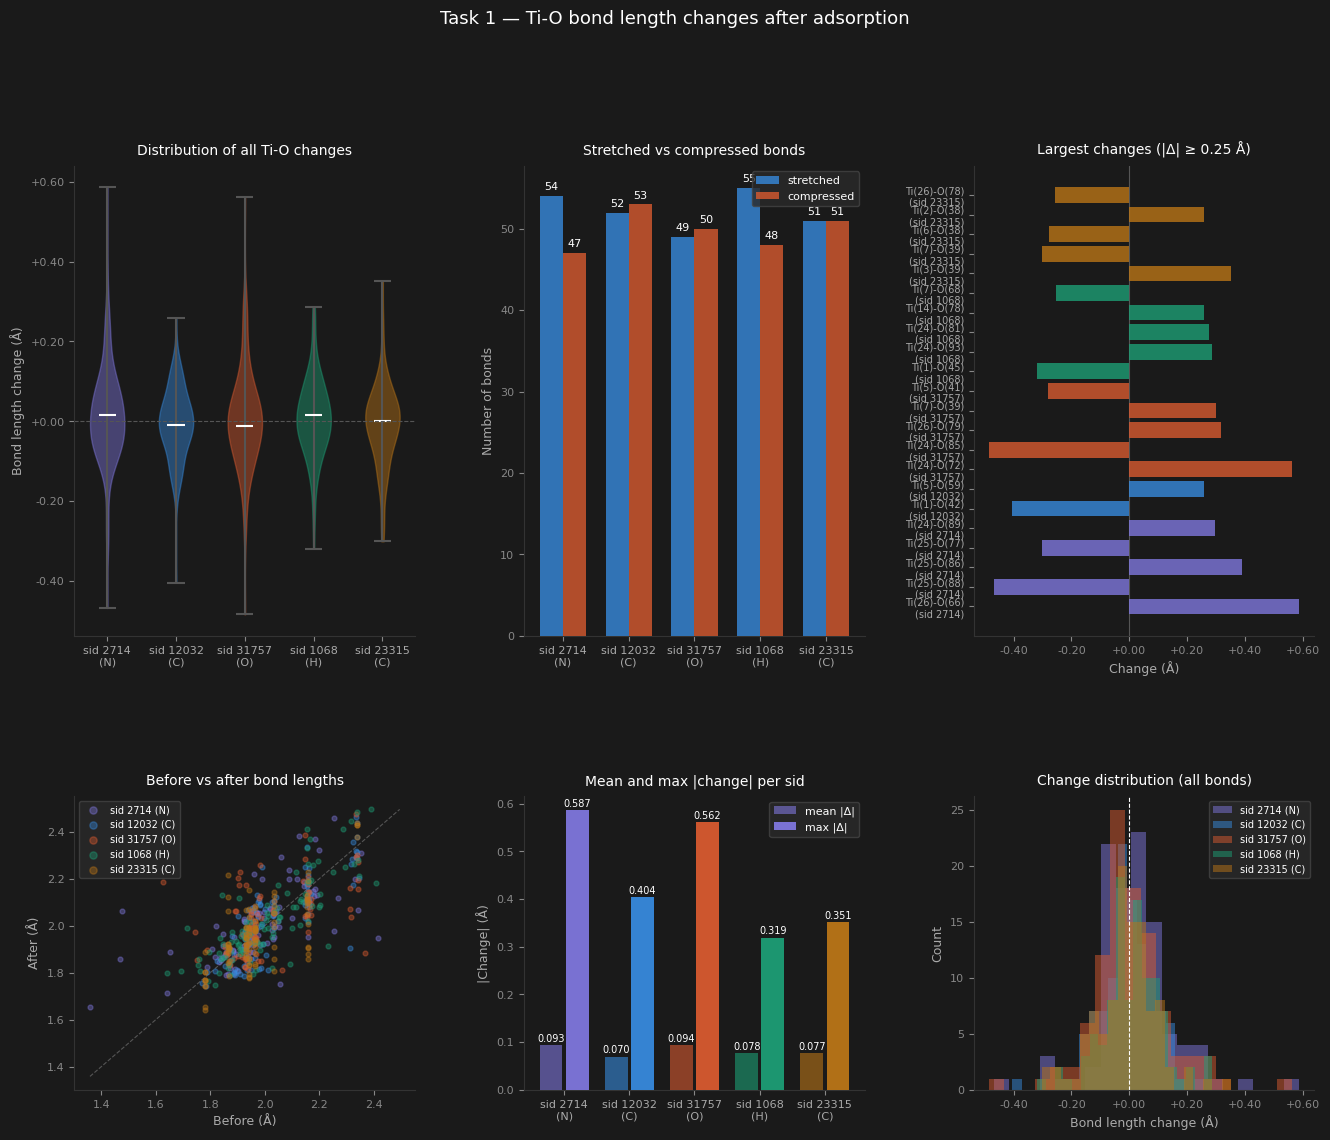

Saved → task1_bond_length_chart.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Real data from Task 1 output ──────────────────────────────────
data = {
    "2714": {
        "adsorbate": "N",
        "bonds": {
            "Ti(0)-O(43)": (1.6512, 1.8856), "Ti(4)-O(36)": (1.9836, 1.9193),
            "Ti(4)-O(44)": (2.2548, 1.9774), "Ti(4)-O(47)": (1.8183, 1.8681),
            "Ti(4)-O(56)": (1.8757, 1.8533), "Ti(5)-O(37)": (1.9971, 2.0592),
            "Ti(5)-O(45)": (2.2688, 2.1193), "Ti(5)-O(46)": (1.8634, 1.7957),
            "Ti(5)-O(57)": (1.8332, 1.8454), "Ti(6)-O(36)": (1.9478, 1.8582),
            "Ti(6)-O(46)": (1.8449, 1.9633), "Ti(6)-O(54)": (2.1460, 2.1009),
            "Ti(6)-O(57)": (2.1185, 2.2002), "Ti(6)-O(62)": (2.0311, 2.0461),
            "Ti(7)-O(43)": (1.9894, 2.1963), "Ti(7)-O(47)": (1.8478, 1.9121),
            "Ti(7)-O(56)": (2.1264, 2.3793), "Ti(7)-O(63)": (2.0322, 1.9512),
            "Ti(8)-O(45)": (2.0344, 2.1041), "Ti(8)-O(51)": (2.0398, 2.0639),
            "Ti(8)-O(54)": (1.9284, 1.9562), "Ti(9)-O(44)": (2.0182, 2.0701),
            "Ti(9)-O(50)": (2.0363, 1.9991), "Ti(9)-O(56)": (2.3527, 2.3074),
            "Ti(9)-O(61)": (1.9558, 1.9169), "Ti(10)-O(36)": (2.1979, 2.3219),
            "Ti(10)-O(38)": (2.0500, 2.0791), "Ti(10)-O(44)": (2.1773, 2.1490),
            "Ti(10)-O(54)": (1.8453, 1.8685), "Ti(11)-O(37)": (2.1591, 1.9525),
            "Ti(11)-O(45)": (2.1927, 2.1312), "Ti(11)-O(51)": (1.8884, 1.7940),
            "Ti(11)-O(55)": (1.8337, 1.8610), "Ti(12)-O(52)": (1.8069, 1.9002),
            "Ti(12)-O(56)": (1.9440, 1.8894), "Ti(12)-O(63)": (2.0254, 2.0078),
            "Ti(12)-O(72)": (1.9765, 1.9581), "Ti(13)-O(57)": (1.9656, 2.0573),
            "Ti(13)-O(60)": (2.3309, 2.1984), "Ti(13)-O(62)": (2.0263, 1.9820),
            "Ti(13)-O(73)": (1.9556, 1.8891), "Ti(14)-O(48)": (1.8717, 1.8179),
            "Ti(14)-O(58)": (1.8825, 1.8931), "Ti(14)-O(62)": (1.9227, 2.0267),
            "Ti(14)-O(70)": (2.1542, 2.1120), "Ti(14)-O(73)": (2.1443, 2.1865),
            "Ti(14)-O(78)": (1.9526, 1.9884), "Ti(15)-O(59)": (1.8726, 1.8997),
            "Ti(15)-O(63)": (1.9270, 2.0165), "Ti(15)-O(71)": (2.1617, 2.0787),
            "Ti(15)-O(72)": (2.1632, 2.0926), "Ti(15)-O(79)": (1.9470, 1.9327),
            "Ti(16)-O(60)": (1.9782, 2.0514), "Ti(16)-O(70)": (1.9422, 1.9779),
            "Ti(16)-O(73)": (2.3367, 2.2884), "Ti(16)-O(74)": (1.7879, 1.8249),
            "Ti(16)-O(76)": (1.9336, 1.8602), "Ti(17)-O(61)": (1.9388, 1.9204),
            "Ti(17)-O(66)": (2.0490, 2.0200), "Ti(17)-O(71)": (1.9197, 1.9621),
            "Ti(17)-O(77)": (2.0299, 1.9440), "Ti(18)-O(50)": (1.9492, 2.0522),
            "Ti(18)-O(61)": (2.1631, 2.1012), "Ti(18)-O(66)": (1.9608, 1.9398),
            "Ti(18)-O(68)": (1.8558, 1.7886), "Ti(18)-O(70)": (1.8529, 1.8759),
            "Ti(19)-O(51)": (1.9711, 2.0523), "Ti(19)-O(60)": (2.1450, 2.1704),
            "Ti(19)-O(67)": (1.8910, 1.8155), "Ti(19)-O(69)": (1.8943, 1.8777),
            "Ti(20)-O(64)": (1.9588, 2.2208), "Ti(20)-O(72)": (1.9282, 1.9429),
            "Ti(20)-O(79)": (1.9978, 2.0324), "Ti(20)-O(88)": (2.0194, 2.0741),
            "Ti(21)-O(73)": (1.9758, 2.0419), "Ti(21)-O(76)": (2.3398, 2.0667),
            "Ti(21)-O(78)": (2.0504, 1.9924), "Ti(21)-O(87)": (1.9170, 1.9024),
            "Ti(22)-O(64)": (1.9237, 2.0192), "Ti(22)-O(78)": (1.8855, 1.9522),
            "Ti(22)-O(85)": (2.1789, 2.1268), "Ti(22)-O(87)": (2.0994, 2.0314),
            "Ti(22)-O(90)": (2.0588, 2.2916), "Ti(23)-O(65)": (1.8392, 1.8531),
            "Ti(23)-O(79)": (1.9590, 2.0808), "Ti(23)-O(86)": (2.1830, 2.3662),
            "Ti(23)-O(88)": (2.1830, 2.1572), "Ti(23)-O(91)": (1.9226, 1.9115),
            "Ti(24)-O(82)": (1.8214, 1.9984), "Ti(24)-O(85)": (2.0878, 2.2354),
            "Ti(24)-O(89)": (1.3588, 1.6547), "Ti(25)-O(77)": (2.0559, 1.7529),
            "Ti(25)-O(86)": (1.4684, 1.8594), "Ti(25)-O(88)": (2.4154, 1.9478),
            "Ti(26)-O(66)": (1.4771, 2.0637), "Ti(26)-O(77)": (2.2519, 2.4562),
            "Ti(26)-O(85)": (1.8821, 1.8976), "Ti(27)-O(67)": (2.0866, 2.2000),
            "Ti(27)-O(84)": (2.0069, 1.9252), "Ti(28)-O(84)": (1.6417, 1.7144),
            "Ti(31)-O(80)": (1.9005, 1.8069),
        }
    },
    "12032": {
        "adsorbate": "C",
        "bonds": {
            "Ti(0)-O(40)": (1.9352, 1.8414), "Ti(1)-O(37)": (2.0410, 2.1227),
            "Ti(1)-O(42)": (2.3107, 1.9065), "Ti(1)-O(46)": (1.9317, 1.8672),
            "Ti(4)-O(35)": (1.9498, 1.8125), "Ti(4)-O(42)": (1.8880, 1.7994),
            "Ti(4)-O(46)": (2.3147, 2.2606), "Ti(4)-O(49)": (1.9855, 1.8210),
            "Ti(4)-O(58)": (2.0011, 2.0722), "Ti(5)-O(36)": (1.9550, 2.0593),
            "Ti(5)-O(43)": (1.9351, 1.8118), "Ti(5)-O(47)": (2.3245, 2.3544),
            "Ti(5)-O(48)": (2.0037, 1.8769), "Ti(5)-O(59)": (1.9900, 2.2477),
            "Ti(6)-O(35)": (1.8804, 1.9563), "Ti(6)-O(44)": (1.8983, 1.8108),
            "Ti(6)-O(48)": (1.8881, 1.8034), "Ti(6)-O(56)": (2.1549, 2.3325),
            "Ti(6)-O(59)": (2.1463, 2.0896), "Ti(6)-O(64)": (1.9831, 2.0920),
            "Ti(7)-O(45)": (1.8890, 1.7913), "Ti(7)-O(58)": (2.1596, 2.0477),
            "Ti(7)-O(65)": (1.9775, 1.8163), "Ti(8)-O(53)": (2.0368, 2.0531),
            "Ti(8)-O(56)": (1.9279, 1.8953), "Ti(8)-O(59)": (2.3321, 2.3177),
            "Ti(8)-O(62)": (1.9665, 1.9407), "Ti(9)-O(58)": (2.3391, 2.4349),
            "Ti(9)-O(63)": (1.9640, 1.9258), "Ti(10)-O(35)": (2.1588, 2.1867),
            "Ti(10)-O(37)": (1.9852, 1.9978), "Ti(10)-O(46)": (2.1621, 2.2437),
            "Ti(10)-O(56)": (1.8526, 1.8300), "Ti(11)-O(36)": (2.1468, 2.0331),
            "Ti(11)-O(38)": (1.9896, 2.0077), "Ti(11)-O(47)": (2.1580, 2.1938),
            "Ti(11)-O(53)": (1.9335, 1.9126), "Ti(12)-O(50)": (1.9339, 1.9125),
            "Ti(12)-O(54)": (1.7838, 1.7444), "Ti(12)-O(58)": (1.9523, 2.0757),
            "Ti(12)-O(63)": (2.3376, 2.3748), "Ti(12)-O(65)": (2.0271, 2.1011),
            "Ti(12)-O(74)": (1.9707, 1.9957), "Ti(13)-O(59)": (1.9414, 1.9206),
            "Ti(13)-O(62)": (2.3367, 2.3146), "Ti(13)-O(64)": (2.0281, 2.0388),
            "Ti(13)-O(75)": (1.9760, 2.0346), "Ti(14)-O(50)": (1.8635, 1.9063),
            "Ti(14)-O(64)": (1.9246, 1.8281), "Ti(14)-O(72)": (2.1607, 2.1365),
            "Ti(14)-O(75)": (2.1564, 2.1135), "Ti(14)-O(80)": (1.9566, 2.0663),
            "Ti(15)-O(61)": (1.8669, 1.8374), "Ti(15)-O(65)": (1.9284, 1.9777),
            "Ti(15)-O(74)": (2.1585, 2.1483), "Ti(15)-O(81)": (1.9550, 1.9369),
            "Ti(16)-O(69)": (2.0330, 1.9905), "Ti(16)-O(72)": (1.9282, 1.9722),
            "Ti(16)-O(75)": (2.3336, 2.2911), "Ti(16)-O(76)": (1.7891, 1.8033),
            "Ti(16)-O(78)": (1.9659, 1.9794), "Ti(17)-O(63)": (1.9586, 2.0108),
            "Ti(17)-O(74)": (2.3326, 2.4623), "Ti(17)-O(79)": (1.9647, 1.8612),
            "Ti(18)-O(50)": (2.1559, 2.1256), "Ti(18)-O(52)": (1.9421, 1.9636),
            "Ti(18)-O(63)": (2.1545, 2.1766), "Ti(18)-O(68)": (1.9421, 1.9550),
            "Ti(19)-O(53)": (1.9404, 1.9802), "Ti(19)-O(62)": (2.1527, 2.1669),
            "Ti(20)-O(66)": (1.9331, 1.9468), "Ti(20)-O(74)": (1.9547, 1.9318),
            "Ti(20)-O(79)": (2.3452, 2.2034), "Ti(20)-O(91)": (1.9791, 2.1098),
            "Ti(21)-O(75)": (1.9530, 1.9642), "Ti(21)-O(80)": (2.0331, 2.0895),
            "Ti(21)-O(90)": (1.9807, 2.0867), "Ti(22)-O(66)": (1.8566, 1.8869),
            "Ti(22)-O(80)": (1.9247, 1.7870), "Ti(22)-O(88)": (2.1591, 2.0150),
            "Ti(22)-O(90)": (2.1604, 2.1113), "Ti(23)-O(67)": (1.8591, 1.8773),
            "Ti(23)-O(89)": (2.1682, 2.1330), "Ti(23)-O(91)": (2.1596, 2.2143),
            "Ti(23)-O(96)": (1.9717, 2.1289), "Ti(24)-O(78)": (1.9392, 1.8728),
            "Ti(24)-O(85)": (2.0128, 1.8125), "Ti(24)-O(88)": (1.9367, 2.0678),
            "Ti(24)-O(90)": (2.3247, 2.1720), "Ti(24)-O(92)": (1.8258, 1.8493),
            "Ti(25)-O(79)": (1.9468, 1.9574), "Ti(25)-O(84)": (1.9919, 1.9198),
            "Ti(25)-O(89)": (1.9421, 2.0330), "Ti(25)-O(91)": (2.3177, 2.2825),
            "Ti(25)-O(94)": (1.9752, 2.1013), "Ti(26)-O(66)": (2.1505, 2.1082),
            "Ti(26)-O(68)": (1.9618, 1.9730), "Ti(26)-O(84)": (1.9100, 1.7950),
            "Ti(26)-O(86)": (1.8997, 2.0412), "Ti(27)-O(69)": (1.9553, 2.0197),
            "Ti(27)-O(78)": (2.1479, 2.2497), "Ti(27)-O(85)": (1.9234, 1.8999),
            "Ti(27)-O(87)": (1.8849, 1.8744), "Ti(28)-O(87)": (1.7700, 1.7546),
            "Ti(30)-O(92)": (1.8174, 1.8052),
        }
    },
    "31757": {
        "adsorbate": "O",
        "bonds": {
            "Ti(0)-O(39)": (1.7445, 1.9724), "Ti(4)-O(32)": (1.9446, 1.9582),
            "Ti(4)-O(40)": (2.3134, 2.1617), "Ti(4)-O(43)": (1.9728, 1.9288),
            "Ti(4)-O(52)": (1.9384, 1.8846), "Ti(5)-O(33)": (1.9477, 2.0606),
            "Ti(5)-O(41)": (2.3167, 2.0353), "Ti(5)-O(42)": (1.9856, 1.8490),
            "Ti(5)-O(53)": (1.9281, 1.8570), "Ti(6)-O(32)": (1.8866, 1.8621),
            "Ti(6)-O(38)": (1.8902, 2.0617), "Ti(6)-O(42)": (1.9152, 1.8651),
            "Ti(6)-O(50)": (2.1552, 2.0448), "Ti(6)-O(53)": (2.1452, 2.2834),
            "Ti(6)-O(58)": (1.9681, 2.0063), "Ti(7)-O(39)": (1.9027, 2.2013),
            "Ti(7)-O(43)": (1.9159, 1.9628), "Ti(7)-O(52)": (2.1471, 2.3850),
            "Ti(7)-O(59)": (1.9674, 1.8812), "Ti(8)-O(41)": (1.9832, 2.2573),
            "Ti(8)-O(50)": (1.9299, 1.9619), "Ti(8)-O(53)": (2.3389, 2.3011),
            "Ti(8)-O(56)": (1.9567, 1.9812), "Ti(9)-O(40)": (1.9801, 2.1192),
            "Ti(9)-O(46)": (2.0341, 2.0614), "Ti(9)-O(52)": (2.3410, 2.1565),
            "Ti(10)-O(32)": (2.1695, 2.1150), "Ti(10)-O(40)": (2.1614, 2.1417),
            "Ti(10)-O(46)": (1.9338, 1.8512), "Ti(10)-O(50)": (1.8586, 1.8828),
            "Ti(11)-O(33)": (2.1592, 1.9736), "Ti(11)-O(41)": (2.1658, 2.0700),
            "Ti(11)-O(47)": (1.9278, 1.8225), "Ti(11)-O(51)": (1.8552, 1.9154),
            "Ti(12)-O(48)": (1.7891, 1.8978), "Ti(12)-O(52)": (1.9598, 1.9219),
            "Ti(12)-O(57)": (2.3349, 2.4756), "Ti(12)-O(59)": (2.0310, 2.0517),
            "Ti(12)-O(68)": (1.9648, 1.9345), "Ti(13)-O(45)": (1.9302, 1.9194),
            "Ti(13)-O(53)": (1.9629, 2.0174), "Ti(13)-O(69)": (1.9653, 1.9504),
            "Ti(14)-O(58)": (1.9369, 1.9198), "Ti(14)-O(66)": (2.1579, 2.1443),
            "Ti(14)-O(74)": (1.9475, 2.0010), "Ti(15)-O(59)": (1.9374, 1.9704),
            "Ti(15)-O(68)": (2.1556, 2.1164), "Ti(15)-O(75)": (1.9473, 2.0047),
            "Ti(16)-O(56)": (1.9702, 2.0488), "Ti(16)-O(66)": (1.9326, 1.9573),
            "Ti(16)-O(69)": (2.3348, 2.2910), "Ti(16)-O(72)": (1.9367, 1.9761),
            "Ti(17)-O(57)": (1.9656, 1.9472), "Ti(17)-O(62)": (2.0309, 2.0674),
            "Ti(17)-O(73)": (1.9589, 1.9427), "Ti(18)-O(44)": (2.1588, 2.2063),
            "Ti(18)-O(46)": (1.9472, 2.0309), "Ti(18)-O(57)": (2.1560, 2.1248),
            "Ti(18)-O(62)": (1.9371, 1.9888), "Ti(18)-O(64)": (1.8716, 1.8322),
            "Ti(18)-O(66)": (1.8621, 1.8744), "Ti(19)-O(45)": (2.1587, 2.1748),
            "Ti(19)-O(47)": (1.9498, 2.0492), "Ti(19)-O(56)": (2.1546, 2.1026),
            "Ti(19)-O(65)": (1.8723, 1.8494), "Ti(20)-O(60)": (1.9302, 1.9554),
            "Ti(20)-O(68)": (1.9590, 1.9449), "Ti(20)-O(73)": (2.3409, 2.2719),
            "Ti(20)-O(75)": (2.0345, 2.0524), "Ti(20)-O(84)": (1.9806, 2.1247),
            "Ti(21)-O(69)": (1.9560, 1.9662), "Ti(21)-O(72)": (2.3407, 2.1929),
            "Ti(21)-O(74)": (2.0343, 2.0544), "Ti(21)-O(83)": (1.9862, 2.0311),
            "Ti(22)-O(60)": (1.8546, 1.9083), "Ti(22)-O(74)": (1.9288, 1.8252),
            "Ti(22)-O(81)": (2.1557, 2.0380), "Ti(22)-O(83)": (2.1676, 2.0901),
            "Ti(23)-O(61)": (1.8565, 1.8830), "Ti(23)-O(75)": (1.9318, 1.8587),
            "Ti(23)-O(82)": (2.1678, 2.0444), "Ti(24)-O(72)": (1.6253, 2.1873),
            "Ti(24)-O(78)": (2.0630, 1.8127), "Ti(24)-O(81)": (1.9039, 2.1735),
            "Ti(24)-O(83)": (1.9308, 2.1727), "Ti(24)-O(85)": (2.3670, 1.8833),
            "Ti(25)-O(73)": (1.9391, 1.8168), "Ti(25)-O(77)": (1.9733, 1.8508),
            "Ti(25)-O(82)": (1.9434, 1.9895), "Ti(25)-O(84)": (2.3134, 2.0711),
            "Ti(26)-O(60)": (2.1477, 2.0414), "Ti(26)-O(62)": (1.9685, 1.9393),
            "Ti(26)-O(77)": (1.9165, 1.8738), "Ti(26)-O(79)": (1.9099, 2.2271),
            "Ti(26)-O(81)": (1.8671, 1.8320), "Ti(27)-O(72)": (2.1393, 2.1885),
            "Ti(27)-O(78)": (1.9030, 1.8719), "Ti(27)-O(80)": (1.8930, 2.0601),
            "Ti(28)-O(80)": (1.7520, 1.8547),
        }
    },
    "1068": {
        "adsorbate": "H",
        "bonds": {
            "Ti(0)-O(43)": (1.9442, 1.8452), "Ti(1)-O(40)": (2.0823, 2.1367),
            "Ti(1)-O(45)": (2.2312, 1.9122), "Ti(1)-O(49)": (1.8426, 1.8613),
            "Ti(4)-O(38)": (2.0242, 1.8196), "Ti(4)-O(45)": (1.6400, 1.7981),
            "Ti(4)-O(49)": (2.2497, 2.2264), "Ti(4)-O(52)": (1.8637, 1.8207),
            "Ti(4)-O(61)": (2.1413, 2.1024), "Ti(5)-O(39)": (2.0544, 2.0384),
            "Ti(5)-O(46)": (1.7627, 1.8074), "Ti(5)-O(50)": (2.2864, 2.4097),
            "Ti(5)-O(51)": (1.9096, 1.8775), "Ti(5)-O(62)": (2.1156, 2.2271),
            "Ti(6)-O(38)": (1.9306, 1.9474), "Ti(6)-O(47)": (1.9670, 1.8102),
            "Ti(6)-O(51)": (1.6924, 1.8067), "Ti(6)-O(59)": (2.1532, 2.3319),
            "Ti(6)-O(62)": (2.1291, 2.1040), "Ti(7)-O(48)": (1.9548, 1.7941),
            "Ti(7)-O(61)": (2.1727, 2.0818), "Ti(7)-O(68)": (2.0915, 1.8375),
            "Ti(8)-O(50)": (1.9855, 2.0049), "Ti(8)-O(56)": (2.0516, 2.0351),
            "Ti(8)-O(59)": (1.9137, 1.9013), "Ti(8)-O(62)": (2.3146, 2.4435),
            "Ti(8)-O(65)": (1.9709, 1.9316), "Ti(9)-O(61)": (2.3448, 2.2128),
            "Ti(9)-O(66)": (1.9813, 1.9205), "Ti(10)-O(38)": (2.1561, 2.1850),
            "Ti(10)-O(40)": (2.0997, 1.9882), "Ti(10)-O(49)": (2.1777, 2.2577),
            "Ti(10)-O(55)": (1.9284, 1.9416), "Ti(11)-O(39)": (2.1042, 2.0796),
            "Ti(11)-O(41)": (2.1296, 2.0027), "Ti(11)-O(50)": (2.1629, 2.1840),
            "Ti(11)-O(56)": (1.9060, 1.9227), "Ti(11)-O(60)": (1.8394, 1.8596),
            "Ti(12)-O(57)": (1.7904, 1.7633), "Ti(12)-O(61)": (1.9041, 2.1186),
            "Ti(12)-O(66)": (2.3415, 2.2808), "Ti(12)-O(68)": (2.0083, 2.0546),
            "Ti(12)-O(77)": (2.0024, 2.0257), "Ti(13)-O(62)": (1.8777, 1.8555),
            "Ti(13)-O(65)": (2.3381, 2.4824), "Ti(13)-O(67)": (2.0107, 1.9896),
            "Ti(13)-O(78)": (2.0089, 2.0873), "Ti(14)-O(53)": (1.8695, 1.8355),
            "Ti(14)-O(63)": (1.8719, 1.7885), "Ti(14)-O(67)": (1.8651, 1.9106),
            "Ti(14)-O(75)": (2.1659, 2.3701), "Ti(14)-O(78)": (2.1536, 2.4111),
            "Ti(15)-O(68)": (1.8805, 1.9738), "Ti(15)-O(84)": (1.9944, 1.9224),
            "Ti(16)-O(65)": (1.9460, 2.0168), "Ti(16)-O(72)": (2.0247, 1.9527),
            "Ti(16)-O(75)": (1.9313, 1.9878), "Ti(16)-O(79)": (1.8168, 1.7471),
            "Ti(16)-O(81)": (1.9464, 1.9649), "Ti(17)-O(66)": (1.9119, 1.9575),
            "Ti(17)-O(71)": (2.0490, 2.1734), "Ti(17)-O(77)": (2.3256, 2.2612),
            "Ti(17)-O(82)": (2.0461, 2.0751), "Ti(18)-O(53)": (2.1484, 2.1360),
            "Ti(18)-O(66)": (2.1570, 2.2633), "Ti(18)-O(73)": (1.8761, 1.8934),
            "Ti(18)-O(75)": (1.8537, 1.8658), "Ti(19)-O(56)": (1.9361, 1.9678),
            "Ti(19)-O(65)": (2.1341, 2.1111), "Ti(19)-O(72)": (1.9253, 1.9523),
            "Ti(19)-O(74)": (1.9099, 1.8956), "Ti(20)-O(69)": (1.9552, 1.9274),
            "Ti(20)-O(77)": (1.9145, 1.9788), "Ti(20)-O(82)": (2.3903, 2.4940),
            "Ti(20)-O(84)": (2.0100, 2.0402), "Ti(21)-O(78)": (1.9323, 2.0147),
            "Ti(21)-O(83)": (2.0351, 2.0565), "Ti(22)-O(69)": (1.8953, 1.9358),
            "Ti(22)-O(83)": (1.8760, 1.9308), "Ti(22)-O(91)": (2.1688, 2.1931),
            "Ti(23)-O(70)": (1.8300, 1.8814), "Ti(23)-O(84)": (1.9032, 1.9169),
            "Ti(23)-O(92)": (2.1984, 2.0792), "Ti(23)-O(94)": (2.2031, 2.1341),
            "Ti(24)-O(81)": (1.7142, 1.9906), "Ti(24)-O(88)": (1.9209, 1.8882),
            "Ti(24)-O(91)": (2.0311, 1.9678), "Ti(24)-O(93)": (1.8437, 2.1305),
            "Ti(24)-O(95)": (2.4085, 2.1790), "Ti(24)-O(96)": (2.1955, 2.2745),
            "Ti(25)-O(82)": (1.9818, 1.8970), "Ti(25)-O(92)": (1.7550, 1.8339),
            "Ti(25)-O(94)": (2.2949, 2.2509), "Ti(25)-O(97)": (1.9969, 1.9842),
            "Ti(26)-O(69)": (2.1589, 2.0210), "Ti(26)-O(71)": (1.8311, 1.7984),
            "Ti(26)-O(82)": (2.2012, 2.0872), "Ti(26)-O(89)": (1.8458, 1.9238),
            "Ti(26)-O(91)": (1.7951, 1.8895), "Ti(27)-O(72)": (2.0465, 2.0176),
            "Ti(27)-O(81)": (2.1149, 2.0770), "Ti(27)-O(88)": (1.7580, 1.8577),
            "Ti(30)-O(95)": (1.8367, 1.9481),
        }
    },
    "23315": {
        "adsorbate": "C",
        "bonds": {
            "Ti(0)-O(35)": (2.0333, 1.8079), "Ti(0)-O(39)": (1.9302, 1.9461),
            "Ti(0)-O(40)": (1.7811, 1.8031), "Ti(0)-O(42)": (1.9642, 1.9099),
            "Ti(1)-O(38)": (1.9302, 1.9479), "Ti(1)-O(41)": (1.7811, 1.8007),
            "Ti(1)-O(43)": (1.9642, 1.8291), "Ti(2)-O(33)": (2.1594, 2.1896),
            "Ti(2)-O(38)": (1.8638, 2.1206), "Ti(2)-O(48)": (1.9430, 1.9954),
            "Ti(3)-O(36)": (1.9430, 1.9264), "Ti(3)-O(39)": (1.8638, 2.2152),
            "Ti(3)-O(51)": (1.8698, 1.9041), "Ti(4)-O(33)": (1.9303, 1.8749),
            "Ti(4)-O(54)": (1.9642, 1.8841), "Ti(5)-O(37)": (1.7811, 1.6525),
            "Ti(5)-O(45)": (2.0333, 1.9076), "Ti(5)-O(55)": (1.9642, 1.9905),
            "Ti(6)-O(38)": (2.1594, 1.8807), "Ti(6)-O(45)": (1.9430, 1.7955),
            "Ti(7)-O(39)": (2.1594, 1.8585), "Ti(7)-O(44)": (1.9430, 1.8330),
            "Ti(8)-O(42)": (1.9642, 1.9871), "Ti(8)-O(52)": (1.9303, 1.9644),
            "Ti(8)-O(56)": (1.7811, 1.7436), "Ti(9)-O(49)": (2.0333, 1.9939),
            "Ti(9)-O(53)": (1.9303, 1.9884), "Ti(9)-O(55)": (2.3373, 2.4261),
            "Ti(10)-O(48)": (1.9430, 1.9854), "Ti(10)-O(53)": (1.8638, 1.9219),
            "Ti(10)-O(58)": (2.1560, 2.1089), "Ti(10)-O(64)": (1.9430, 1.9741),
            "Ti(12)-O(47)": (1.9302, 1.9034), "Ti(12)-O(50)": (1.7811, 1.7416),
            "Ti(12)-O(55)": (1.9642, 2.0214), "Ti(12)-O(60)": (2.0333, 2.1253),
            "Ti(12)-O(70)": (1.9642, 1.9941), "Ti(13)-O(46)": (1.9302, 1.8932),
            "Ti(13)-O(51)": (1.7811, 1.7661), "Ti(13)-O(54)": (1.9642, 2.0738),
            "Ti(13)-O(58)": (2.3373, 2.3747), "Ti(13)-O(61)": (2.0333, 2.1447),
            "Ti(14)-O(54)": (2.1560, 2.0799), "Ti(14)-O(61)": (1.9430, 1.7827),
            "Ti(15)-O(46)": (1.8638, 1.8911), "Ti(15)-O(53)": (2.1594, 2.0069),
            "Ti(15)-O(55)": (2.1560, 2.0492), "Ti(15)-O(60)": (1.9430, 1.7771),
            "Ti(16)-O(58)": (1.9642, 1.9783), "Ti(16)-O(64)": (2.0333, 2.0818),
            "Ti(16)-O(69)": (1.9302, 1.9181), "Ti(16)-O(71)": (2.3373, 2.4281),
            "Ti(16)-O(75)": (1.9642, 1.9396), "Ti(17)-O(59)": (1.9642, 1.9858),
            "Ti(17)-O(65)": (2.0333, 2.0551), "Ti(17)-O(70)": (2.3373, 2.4382),
            "Ti(17)-O(73)": (1.7811, 1.7668), "Ti(17)-O(74)": (1.9642, 1.9752),
            "Ti(18)-O(65)": (1.9430, 1.9025), "Ti(18)-O(74)": (2.1560, 2.0952),
            "Ti(19)-O(63)": (2.1594, 2.2273), "Ti(19)-O(64)": (1.9430, 1.9317),
            "Ti(19)-O(68)": (1.8638, 1.9233), "Ti(19)-O(75)": (2.1560, 2.1145),
            "Ti(19)-O(81)": (1.9430, 2.1519), "Ti(19)-O(82)": (1.8698, 1.7848),
            "Ti(20)-O(62)": (1.9303, 1.9196), "Ti(20)-O(86)": (1.9642, 2.0823),
            "Ti(21)-O(63)": (1.9303, 1.9001), "Ti(21)-O(71)": (1.9642, 1.9449),
            "Ti(21)-O(77)": (2.0333, 2.0166), "Ti(21)-O(87)": (1.9642, 1.9886),
            "Ti(22)-O(56)": (1.8698, 1.9097), "Ti(22)-O(60)": (1.9430, 2.0382),
            "Ti(22)-O(68)": (2.1594, 2.1006), "Ti(22)-O(70)": (2.1560, 2.1321),
            "Ti(22)-O(76)": (1.9430, 1.8566), "Ti(23)-O(57)": (1.8698, 1.8512),
            "Ti(23)-O(62)": (1.8638, 1.8837), "Ti(24)-O(74)": (1.9642, 1.9874),
            "Ti(24)-O(84)": (1.9303, 1.8623), "Ti(25)-O(75)": (1.9642, 1.9261),
            "Ti(25)-O(81)": (2.0333, 2.1025), "Ti(25)-O(85)": (1.9303, 1.9512),
            "Ti(25)-O(88)": (1.7811, 1.6429), "Ti(26)-O(78)": (2.1594, 1.9036),
            "Ti(26)-O(81)": (1.9430, 1.8335), "Ti(26)-O(84)": (1.8638, 1.8398),
            "Ti(27)-O(79)": (2.1594, 1.9080), "Ti(27)-O(80)": (1.9430, 1.8605),
            "Ti(28)-O(79)": (1.9302, 2.0652), "Ti(28)-O(82)": (1.7811, 1.8894),
            "Ti(28)-O(86)": (1.9642, 1.9763), "Ti(28)-O(89)": (2.0333, 1.8599),
            "Ti(29)-O(78)": (1.9302, 1.9951), "Ti(29)-O(83)": (1.7811, 1.7677),
            "Ti(29)-O(87)": (1.9642, 1.8365), "Ti(30)-O(76)": (1.9430, 2.0711),
            "Ti(30)-O(78)": (1.8638, 2.0614), "Ti(31)-O(73)": (1.8698, 1.9014),
            "Ti(31)-O(79)": (1.8638, 1.9088), "Ti(31)-O(90)": (1.9430, 1.9593),
        }
    },
}

COLORS = {
    "2714": "#7F77DD", "12032": "#378ADD",
    "31757": "#D85A30", "1068": "#1D9E75", "23315": "#BA7517"
}

# ── Compute changes ───────────────────────────────────────────────
def get_changes(bonds):
    changes = [after - before for before, after in bonds.values()]
    return np.array(changes)

# ── Figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12), facecolor="#1a1a1a")
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        height_ratios=[1.6, 1],
                        hspace=0.42, wspace=0.32)

axes_top = [fig.add_subplot(gs[0, i]) for i in range(3)]
axes_bot = [fig.add_subplot(gs[1, i]) for i in range(3)]

for ax in axes_top + axes_bot:
    ax.set_facecolor("#1a1a1a")
    ax.tick_params(colors="#888888", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#333333")

sids = list(data.keys())

# ── Plot 1 (top-left): distribution of all changes per sid ────────
ax = axes_top[0]
all_changes = [get_changes(data[s]["bonds"]) for s in sids]
vp = ax.violinplot(all_changes, positions=range(len(sids)),
                   showmedians=True, showextrema=True)
for body, sid in zip(vp["bodies"], sids):
    body.set_facecolor(COLORS[sid]); body.set_alpha(0.45)
    body.set_edgecolor(COLORS[sid])
vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(1.5)
vp["cmaxes"].set_color("#555"); vp["cmins"].set_color("#555")
vp["cbars"].set_color("#555")
ax.axhline(0, color="#555555", lw=0.8, ls="--")
ax.set_xticks(range(len(sids)))
ax.set_xticklabels([f"sid {s}\n({data[s]['adsorbate']})" for s in sids],
                   color="#aaaaaa", fontsize=8)
ax.set_ylabel("Bond length change (Å)", color="#aaaaaa", fontsize=9)
ax.set_title("Distribution of all Ti-O changes",
             color="white", fontsize=10, pad=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:+.2f}"))

# ── Plot 2 (top-center): stretched vs compressed counts ──────────
ax = axes_top[1]
stretched   = [np.sum(get_changes(data[s]["bonds"]) > 0)  for s in sids]
compressed  = [np.sum(get_changes(data[s]["bonds"]) < 0)  for s in sids]
x = np.arange(len(sids)); w = 0.35
b1 = ax.bar(x - w/2, stretched,  width=w, color="#378ADD", alpha=0.8,
            label="stretched", edgecolor="none", zorder=3)
b2 = ax.bar(x + w/2, compressed, width=w, color="#D85A30", alpha=0.8,
            label="compressed", edgecolor="none", zorder=3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha="center", va="bottom",
            fontsize=8, color="white")
ax.set_xticks(x)
ax.set_xticklabels([f"sid {s}\n({data[s]['adsorbate']})" for s in sids],
                   color="#aaaaaa", fontsize=8)
ax.set_ylabel("Number of bonds", color="#aaaaaa", fontsize=9)
ax.set_title("Stretched vs compressed bonds",
             color="white", fontsize=10, pad=8)
ax.legend(facecolor="#2a2a2a", edgecolor="#444", labelcolor="white",
          fontsize=8, loc="upper right")

# ── Plot 3 (top-right): top 10 largest changes per sid ───────────
ax = axes_top[2]
threshold = 0.25
colors_bar, labels_bar, values_bar = [], [], []
for sid in sids:
    changes = get_changes(data[sid]["bonds"])
    bonds   = list(data[sid]["bonds"].keys())
    big     = [(b, c) for b, c in zip(bonds, changes) if abs(c) >= threshold]
    big.sort(key=lambda x: abs(x[1]), reverse=True)
    for bond, change in big[:5]:
        labels_bar.append(f"{bond}\n(sid {sid})")
        values_bar.append(change)
        colors_bar.append(COLORS[sid])

y = np.arange(len(labels_bar))
bars = ax.barh(y, values_bar, color=colors_bar, alpha=0.8,
               edgecolor="none", zorder=3)
ax.axvline(0, color="#555555", lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(labels_bar, color="#aaaaaa", fontsize=7)
ax.set_xlabel("Change (Å)", color="#aaaaaa", fontsize=9)
ax.set_title(f"Largest changes (|Δ| ≥ {threshold} Å)",
             color="white", fontsize=10, pad=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:+.2f}"))

# ── Plot 4 (bot-left): before vs after scatter ────────────────────
ax = axes_bot[0]
for sid in sids:
    before = [b for b, a in data[sid]["bonds"].values()]
    after  = [a for b, a in data[sid]["bonds"].values()]
    ax.scatter(before, after, color=COLORS[sid], alpha=0.4, s=12,
               label=f"sid {sid} ({data[sid]['adsorbate']})", zorder=3)
mn = min(min(b for b,a in data[s]["bonds"].values()) for s in sids)
mx = max(max(a for b,a in data[s]["bonds"].values()) for s in sids)
ax.plot([mn, mx], [mn, mx], color="#555555", lw=0.8, ls="--", zorder=2)
ax.set_xlabel("Before (Å)", color="#aaaaaa", fontsize=9)
ax.set_ylabel("After (Å)",  color="#aaaaaa", fontsize=9)
ax.set_title("Before vs after bond lengths",
             color="white", fontsize=10, pad=8)
ax.legend(facecolor="#2a2a2a", edgecolor="#444", labelcolor="white",
          fontsize=7, markerscale=1.5)

# ── Plot 5 (bot-center): mean absolute change per sid ─────────────
ax = axes_bot[1]
mean_abs = [np.mean(np.abs(get_changes(data[s]["bonds"]))) for s in sids]
max_abs  = [np.max(np.abs(get_changes(data[s]["bonds"]))) for s in sids]
x = np.arange(len(sids))
b1 = ax.bar(x - 0.2, mean_abs, width=0.35,
            color=[COLORS[s] for s in sids], alpha=0.6,
            edgecolor="none", label="mean |Δ|", zorder=3)
b2 = ax.bar(x + 0.2, max_abs, width=0.35,
            color=[COLORS[s] for s in sids], alpha=0.95,
            edgecolor="none", label="max |Δ|", zorder=3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            fontsize=7, color="white")
ax.set_xticks(x)
ax.set_xticklabels([f"sid {s}\n({data[s]['adsorbate']})" for s in sids],
                   color="#aaaaaa", fontsize=8)
ax.set_ylabel("|Change| (Å)", color="#aaaaaa", fontsize=9)
ax.set_title("Mean and max |change| per sid",
             color="white", fontsize=10, pad=8)
ax.legend(facecolor="#2a2a2a", edgecolor="#444", labelcolor="white",
          fontsize=8)

# ── Plot 6 (bot-right): histogram of all changes combined ─────────
ax = axes_bot[2]
for sid in sids:
    ch = get_changes(data[sid]["bonds"])
    ax.hist(ch, bins=20, color=COLORS[sid], alpha=0.5,
            label=f"sid {sid} ({data[sid]['adsorbate']})", edgecolor="none")
ax.axvline(0, color="white", lw=0.8, ls="--")
ax.set_xlabel("Bond length change (Å)", color="#aaaaaa", fontsize=9)
ax.set_ylabel("Count", color="#aaaaaa", fontsize=9)
ax.set_title("Change distribution (all bonds)",
             color="white", fontsize=10, pad=8)
ax.legend(facecolor="#2a2a2a", edgecolor="#444", labelcolor="white",
          fontsize=7)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f"{v:+.2f}"))

plt.suptitle("Task 1 — Ti-O bond length changes after adsorption",
             color="white", fontsize=13, fontweight="500", y=1.01)

plt.savefig("task1_bond_length_chart.png", dpi=150,
            bbox_inches="tight", facecolor="#1a1a1a")
plt.show()
print("Saved → task1_bond_length_chart.png")

## The Ti(5c) Displacement And Adsorption Site

In [ ]:
# ══════════════════════════════════════════════════════════════════
# TASK 2: Ti5c DISPLACEMENT + ADSORPTION SITE TABLE
# ══════════════════════════════════════════════════════════════════

def measure_ti5c_displacement(sid_frames):
    print("\n" + "=" * 65)
    print("TASK 2: Ti5c DISPLACEMENT ACROSS TRAJECTORY")
    print("=" * 65)

    all_rows = []
    summary  = []

    for sid, frames in sid_frames.items():
        if not frames:
            continue

        # ── Use first valid frame as reference ────────────────────
        ref_fid, data_ref = get_reference_frame(frames)
        if data_ref is None:
            print(f"sid={sid}: no valid reference frame")
            continue

        pos_ref  = data_ref.pos.numpy()
        nums_ref = data_ref.atomic_numbers.numpy().astype(int)
        tags_ref = data_ref.tags.numpy().astype(int)

        ads_type = next(
            (chemical_symbols[n] for n, t in zip(nums_ref, tags_ref)
             if t == 2), "?"
        )

        # ── Find Ti5c ─────────────────────────────────────────────
        ti5c_set = find_ti5c_indices(pos_ref, nums_ref, tags_ref, cutoff=3.0)

        # If not found at 3.0 Å try wider cutoff
        if not ti5c_set:
            for cutoff_try in [3.2, 3.5, 4.0]:
                ti5c_set = find_ti5c_indices(
                    pos_ref, nums_ref, tags_ref, cutoff=cutoff_try
                )
                if ti5c_set:
                    print(f"  sid={sid}: Ti5c found at cutoff={cutoff_try} Å")
                    break

        print(f"\nsid={sid} | Adsorbate={ads_type} | "
              f"ref fid={ref_fid} | Ti5c={len(ti5c_set)}")

        if not ti5c_set:
            print(f"  No Ti5c found — skipping")
            continue

        # ── Store initial Ti5c positions ──────────────────────────
        ti5c_init_pos = {i: pos_ref[i].copy() for i in ti5c_set}

        # ── Track across all frames ───────────────────────────────
        print(f"  {'fid':<8}", end="")
        for ti_idx in sorted(ti5c_set):
            print(f"  Ti5c({ti_idx}) disp(Å) ", end="")
        print()
        print(f"  {'-'*60}")

        for fid, frame_idx, d in frames:
            pos_curr = d.pos.numpy()

            for ti_idx in ti5c_set:
                disp = float(np.linalg.norm(
                    pos_curr[ti_idx] - ti5c_init_pos[ti_idx]
                ))
                all_rows.append({
                    "sid":          sid,
                    "adsorbate":    ads_type,
                    "fid":          fid,
                    "Ti5c_idx":     ti_idx,
                    "displacement": round(disp, 4),
                    "intensity":    (
                        "Strong"   if disp > 0.5 else
                        "Moderate" if disp > 0.2 else
                        "Weak"
                    )
                })

            print(f"  {fid:<8}", end="")
            for ti_idx in sorted(ti5c_set):
                row = next(r for r in reversed(all_rows)
                           if r["sid"] == sid and
                           r["fid"] == fid and
                           r["Ti5c_idx"] == ti_idx)
                print(f"  {row['displacement']:<22.4f}", end="")
            print()

        # ── Summary at last frame ─────────────────────────────────
        last_fid  = frames[-1][0]
        last_rows = [r for r in all_rows
                     if r["sid"] == sid and r["fid"] == last_fid]
        if last_rows:
            max_d = max(r["displacement"] for r in last_rows)
            avg_d = np.mean([r["displacement"] for r in last_rows])
            summary.append({
                "sid":              sid,
                "adsorbate":        ads_type,
                "n_Ti5c":           len(ti5c_set),
                "ref_fid":          ref_fid,
                "max_displacement": round(max_d, 4),
                "avg_displacement": round(avg_d, 4),
                "interaction":      (
                    "Strong"   if max_d > 0.5 else
                    "Moderate" if max_d > 0.2 else
                    "Weak"
                )
            })

    df_disp    = pd.DataFrame(all_rows)
    df_summary = pd.DataFrame(summary)
    df_disp.to_csv("ti5c_displacement_full.csv",    index=False)
    df_summary.to_csv("ti5c_displacement_summary.csv", index=False)

    print(f"\n{'='*65}")
    print(f"FINAL SUMMARY")
    print(f"{'='*65}")
    print(df_summary.to_string(index=False))
    print(f"\nSaved → ti5c_displacement_full.csv")
    print(f"Saved → ti5c_displacement_summary.csv")

    return df_disp, df_summary
df_disp, df_summary = measure_ti5c_displacement(sid_frames)
print(f"ti5c_displacement_full.csv    → Task 2")
print(f"ti5c_displacement_summary.csv → Task 2 summary")



TASK 2: Ti5c DISPLACEMENT ACROSS TRAJECTORY

sid=2714 | Adsorbate=N | ref fid=0 | Ti5c=1
  fid       Ti5c(24) disp(Å) 
  ------------------------------------------------------------
  0         0.0000                
  1         0.0009                
  2         0.0015                
  3         0.1734                
  4         0.2119                
  5         0.1250                
  6         0.1310                
  7         0.1253                
  8         0.1745                
  9         0.2045                
  10        0.2365                
  11        0.2166                
  12        0.2156                
  13        0.2154                
  14        0.2149                
  15        0.2170                
  16        0.2768                
  17        0.3045                
  18        0.3122                
  19        0.3162                
  20        0.3240                
  21        0.3462                
  22        0.4005                
  23        

## Visualize The Result Of Task 2

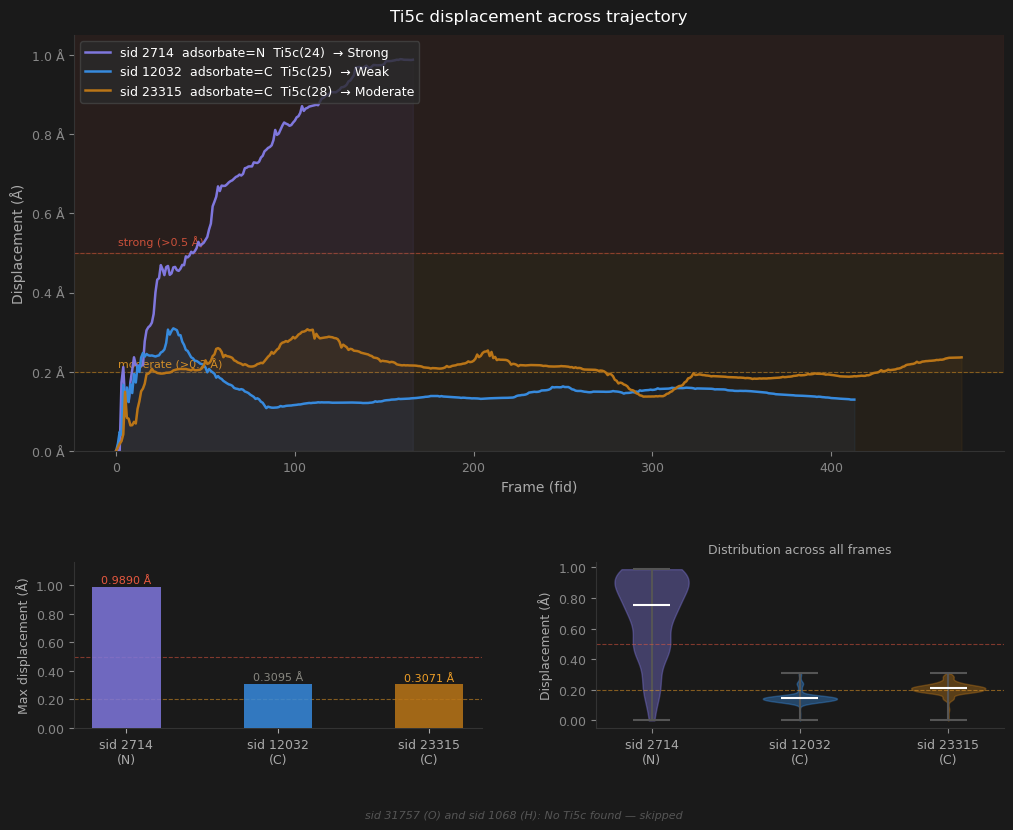

In [67]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Real data from your output ────────────────────────────────────
data = {
    "2714": {
        "adsorbate": "N", "ti5c_idx": 24,
        "fid":  [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166],
        "disp": [0.0000,0.0009,0.0015,0.1734,0.2119,0.1250,0.1310,0.1253,0.1745,0.2045,0.2365,0.2166,0.2156,0.2154,0.2149,0.2170,0.2768,0.3045,0.3122,0.3162,0.3240,0.3462,0.4005,0.4324,0.4361,0.4691,0.4585,0.4439,0.4642,0.4670,0.4446,0.4484,0.4634,0.4646,0.4565,0.4546,0.4602,0.4698,0.4689,0.4913,0.4886,0.4931,0.5028,0.4992,0.5042,0.5120,0.5278,0.5183,0.5219,0.5256,0.5330,0.5403,0.5595,0.5739,0.6175,0.6292,0.6418,0.6679,0.6561,0.6699,0.6690,0.6693,0.6730,0.6778,0.6811,0.6832,0.6875,0.6918,0.6937,0.6977,0.6953,0.6994,0.7136,0.7150,0.7180,0.7184,0.7183,0.7284,0.7276,0.7269,0.7303,0.7406,0.7451,0.7564,0.7603,0.7650,0.7673,0.7716,0.7845,0.8103,0.7979,0.8013,0.8114,0.8214,0.8291,0.8263,0.8244,0.8208,0.8228,0.8290,0.8340,0.8422,0.8450,0.8534,0.8704,0.8584,0.8643,0.8660,0.8693,0.8704,0.8717,0.8724,0.8739,0.8728,0.8815,0.8897,0.8915,0.8957,0.8982,0.9002,0.9063,0.9057,0.9057,0.9055,0.9089,0.9119,0.9179,0.9186,0.9206,0.9247,0.9329,0.9351,0.9418,0.9483,0.9680,0.9684,0.9693,0.9683,0.9664,0.9699,0.9726,0.9682,0.9663,0.9704,0.9744,0.9739,0.9735,0.9738,0.9739,0.9741,0.9769,0.9841,0.9841,0.9841,0.9845,0.9853,0.9863,0.9876,0.9872,0.9890,0.9886,0.9875,0.9875,0.9874,0.9872,0.9869,0.9876],
    },
    "12032": {
        "adsorbate": "C", "ti5c_idx": 25,
        "fid":  list(range(414)),
        "disp": [0.0000,0.0188,0.0488,0.0398,0.1668,0.0882,0.1604,0.1234,0.1685,0.1462,0.1946,0.1729,0.2140,0.1995,0.2359,0.2473,0.2381,0.2449,0.2416,0.2405,0.2411,0.2398,0.2385,0.2401,0.2414,0.2484,0.2511,0.2564,0.2727,0.3063,0.2937,0.3031,0.3095,0.3071,0.3049,0.2921,0.2923,0.2759,0.2677,0.2552,0.2525,0.2442,0.2364,0.2337,0.2278,0.2271,0.2244,0.2205,0.2193,0.2171,0.2106,0.1986,0.2069,0.2019,0.1984,0.1950,0.1851,0.1890,0.1841,0.1818,0.1769,0.1738,0.1709,0.1682,0.1670,0.1645,0.1591,0.1574,0.1566,0.1548,0.1561,0.1546,0.1502,0.1485,0.1463,0.1423,0.1393,0.1366,0.1314,0.1330,0.1302,0.1244,0.1217,0.1150,0.1081,0.1118,0.1104,0.1093,0.1092,0.1095,0.1098,0.1108,0.1135,0.1121,0.1126,0.1138,0.1143,0.1145,0.1148,0.1156,0.1160,0.1165,0.1173,0.1174,0.1184,0.1193,0.1199,0.1203,0.1212,0.1208,0.1215,0.1216,0.1220,0.1229,0.1224,0.1228,0.1225,0.1226,0.1226,0.1226,0.1222,0.1218,0.1218,0.1218,0.1218,0.1219,0.1220,0.1220,0.1221,0.1224,0.1222,0.1222,0.1223,0.1222,0.1221,0.1219,0.1219,0.1216,0.1210,0.1210,0.1210,0.1212,0.1218,0.1221,0.1231,0.1254,0.1241,0.1250,0.1250,0.1258,0.1273,0.1280,0.1283,0.1287,0.1296,0.1298,0.1300,0.1306,0.1317,0.1311,0.1313,0.1317,0.1318,0.1319,0.1322,0.1328,0.1331,0.1335,0.1338,0.1343,0.1346,0.1354,0.1359,0.1367,0.1369,0.1375,0.1387,0.1387,0.1387,0.1387,0.1387,0.1375,0.1385,0.1375,0.1372,0.1369,0.1364,0.1361,0.1358,0.1357,0.1353,0.1352,0.1348,0.1340,0.1345,0.1343,0.1337,0.1336,0.1333,0.1327,0.1329,0.1328,0.1326,0.1322,0.1315,0.1318,0.1320,0.1324,0.1325,0.1329,0.1330,0.1333,0.1334,0.1336,0.1340,0.1340,0.1340,0.1340,0.1340,0.1342,0.1344,0.1345,0.1349,0.1362,0.1387,0.1400,0.1404,0.1413,0.1415,0.1424,0.1441,0.1474,0.1480,0.1485,0.1494,0.1490,0.1493,0.1504,0.1527,0.1529,0.1531,0.1536,0.1546,0.1568,0.1614,0.1605,0.1610,0.1610,0.1607,0.1609,0.1630,0.1614,0.1615,0.1614,0.1590,0.1557,0.1548,0.1523,0.1515,0.1515,0.1515,0.1506,0.1496,0.1492,0.1485,0.1482,0.1486,0.1498,0.1497,0.1497,0.1496,0.1496,0.1496,0.1495,0.1493,0.1494,0.1495,0.1500,0.1512,0.1504,0.1501,0.1495,0.1486,0.1473,0.1448,0.1463,0.1464,0.1467,0.1475,0.1487,0.1477,0.1500,0.1489,0.1530,0.1518,0.1526,0.1532,0.1534,0.1538,0.1548,0.1541,0.1545,0.1557,0.1581,0.1565,0.1568,0.1569,0.1570,0.1572,0.1574,0.1581,0.1595,0.1589,0.1589,0.1589,0.1588,0.1587,0.1586,0.1591,0.1598,0.1595,0.1593,0.1590,0.1583,0.1568,0.1579,0.1578,0.1577,0.1574,0.1576,0.1575,0.1573,0.1572,0.1570,0.1565,0.1554,0.1557,0.1556,0.1555,0.1554,0.1553,0.1548,0.1534,0.1529,0.1527,0.1525,0.1517,0.1516,0.1515,0.1518,0.1516,0.1515,0.1516,0.1514,0.1512,0.1509,0.1505,0.1501,0.1499,0.1495,0.1488,0.1486,0.1479,0.1477,0.1472,0.1457,0.1452,0.1448,0.1444,0.1433,0.1430,0.1426,0.1424,0.1421,0.1417,0.1415,0.1412,0.1409,0.1408,0.1406,0.1399,0.1398,0.1396,0.1395,0.1393,0.1391,0.1387,0.1385,0.1383,0.1380,0.1379,0.1374,0.1365,0.1371,0.1368,0.1360,0.1357,0.1351,0.1350,0.1345,0.1336,0.1334,0.1330,0.1328,0.1323,0.1320,0.1317,0.1315,0.1312,0.1310,0.1307,0.1297,0.1297,0.1297],
    },
    "23315": {
        "adsorbate": "C", "ti5c_idx": 28,
        "fid":  [0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473],
        "disp": [0.0000,0.0182,0.0249,0.0421,0.1493,0.0838,0.0815,0.0645,0.0651,0.0735,0.0693,0.1064,0.1254,0.1508,0.1575,0.1697,0.1939,0.1952,0.1991,0.2075,0.2010,0.1997,0.1969,0.1962,0.1953,0.1955,0.1961,0.1974,0.1976,0.1981,0.1997,0.2032,0.2045,0.2060,0.2066,0.2071,0.2069,0.2068,0.2070,0.2057,0.2049,0.2034,0.2072,0.2038,0.2038,0.2045,0.2053,0.2089,0.2151,0.2287,0.2198,0.2216,0.2273,0.2393,0.2437,0.2577,0.2595,0.2571,0.2501,0.2367,0.2422,0.2393,0.2385,0.2371,0.2349,0.2288,0.2269,0.2235,0.2218,0.2200,0.2168,0.2190,0.2172,0.2140,0.2132,0.2131,0.2139,0.2158,0.2193,0.2204,0.2226,0.2215,0.2267,0.2325,0.2380,0.2420,0.2499,0.2454,0.2504,0.2559,0.2593,0.2694,0.2734,0.2747,0.2774,0.2757,0.2793,0.2822,0.2879,0.2842,0.2883,0.2938,0.2963,0.3007,0.3013,0.3032,0.3071,0.3046,0.3050,0.3061,0.2838,0.2957,0.2886,0.2843,0.2851,0.2859,0.2866,0.2872,0.2885,0.2876,0.2870,0.2851,0.2845,0.2821,0.2751,0.2611,0.2684,0.2652,0.2618,0.2551,0.2579,0.2567,0.2531,0.2525,0.2521,0.2507,0.2481,0.2470,0.2460,0.2447,0.2436,0.2410,0.2397,0.2360,0.2352,0.2343,0.2316,0.2261,0.2277,0.2268,0.2264,0.2255,0.2238,0.2249,0.2243,0.2224,0.2187,0.2176,0.2169,0.2161,0.2167,0.2160,0.2163,0.2159,0.2159,0.2157,0.2156,0.2152,0.2144,0.2141,0.2131,0.2111,0.2107,0.2105,0.2097,0.2081,0.2092,0.2091,0.2088,0.2082,0.2079,0.2082,0.2091,0.2108,0.2144,0.2120,0.2127,0.2148,0.2156,0.2163,0.2182,0.2184,0.2190,0.2203,0.2209,0.2226,0.2261,0.2243,0.2251,0.2277,0.2328,0.2434,0.2368,0.2400,0.2472,0.2505,0.2511,0.2536,0.2395,0.2500,0.2344,0.2376,0.2294,0.2311,0.2303,0.2303,0.2300,0.2298,0.2285,0.2249,0.2179,0.2200,0.2194,0.2176,0.2141,0.2167,0.2166,0.2163,0.2159,0.2162,0.2165,0.2169,0.2168,0.2167,0.2166,0.2167,0.2164,0.2158,0.2146,0.2150,0.2146,0.2135,0.2133,0.2132,0.2131,0.2132,0.2133,0.2136,0.2143,0.2138,0.2137,0.2132,0.2127,0.2114,0.2117,0.2095,0.2112,0.2092,0.2097,0.2089,0.2066,0.2056,0.2055,0.2052,0.2052,0.2051,0.2051,0.2048,0.2039,0.2021,0.2030,0.2025,0.2009,0.1977,0.1915,0.1948,0.1933,0.1886,0.1797,0.1773,0.1704,0.1726,0.1714,0.1679,0.1663,0.1632,0.1570,0.1541,0.1533,0.1509,0.1456,0.1442,0.1405,0.1395,0.1371,0.1374,0.1373,0.1375,0.1374,0.1376,0.1375,0.1383,0.1378,0.1386,0.1383,0.1383,0.1404,0.1440,0.1452,0.1488,0.1507,0.1554,0.1576,0.1613,0.1639,0.1644,0.1665,0.1729,0.1758,0.1832,0.1845,0.1884,0.1962,0.1918,0.1922,0.1933,0.1929,0.1918,0.1915,0.1906,0.1903,0.1896,0.1883,0.1890,0.1888,0.1886,0.1886,0.1883,0.1882,0.1876,0.1873,0.1866,0.1864,0.1861,0.1862,0.1860,0.1857,0.1851,0.1853,0.1851,0.1847,0.1838,0.1843,0.1840,0.1833,0.1818,0.1827,0.1823,0.1825,0.1832,0.1827,0.1831,0.1829,0.1829,0.1835,0.1835,0.1840,0.1843,0.1845,0.1849,0.1851,0.1858,0.1871,0.1863,0.1867,0.1874,0.1876,0.1882,0.1895,0.1898,0.1905,0.1920,0.1909,0.1911,0.1915,0.1923,0.1940,0.1934,0.1937,0.1944,0.1959,0.1949,0.1948,0.1948,0.1946,0.1940,0.1927,0.1931,0.1928,0.1920,0.1916,0.1909,0.1900,0.1894,0.1884,0.1882,0.1879,0.1878,0.1875,0.1875,0.1877,0.1881,0.1889,0.1884,0.1891,0.1894,0.1900,0.1896,0.1896,0.1912,0.1911,0.1929,0.1952,0.1969,0.1976,0.1982,0.2002,0.2041,0.2014,0.2018,0.2030,0.2054,0.2040,0.2047,0.2052,0.2059,0.2077,0.2082,0.2096,0.2124,0.2136,0.2169,0.2180,0.2185,0.2194,0.2199,0.2217,0.2251,0.2227,0.2234,0.2255,0.2260,0.2268,0.2270,0.2275,0.2277,0.2282,0.2286,0.2297,0.2295,0.2304,0.2303,0.2313,0.2332,0.2341,0.2352,0.2353,0.2355,0.2356,0.2356,0.2358,0.2359,0.2363],
    },
    # sid 31757 and 1068 → No Ti5c found, skipped
}

COLORS = {
    "2714":  "#7F77DD",
    "12032": "#378ADD",
    "23315": "#BA7517",
}
INTERACTION = {
    "2714":  ("Strong",   "#E85940"),
    "12032": ("Weak",     "#888780"),
    "23315": ("Moderate", "#EF9F27"),
}

# ── Figure layout ─────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 9), facecolor="#1a1a1a")
gs  = gridspec.GridSpec(2, 2, figure=fig,
                         height_ratios=[2.5, 1],
                         hspace=0.38, wspace=0.28)

ax_main = fig.add_subplot(gs[0, :])   # full-width trajectory
ax_bar  = fig.add_subplot(gs[1, 0])   # max displacement bar
ax_dist = fig.add_subplot(gs[1, 1])   # displacement distribution

for ax in [ax_main, ax_bar, ax_dist]:
    ax.set_facecolor("#1a1a1a")
    ax.tick_params(colors="#888888", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#333333")

# ── Zone bands ────────────────────────────────────────────────────
for ax in [ax_main]:
    ax.axhspan(0.5, 1.1,  alpha=0.07, color="#E85940", zorder=0)
    ax.axhspan(0.2, 0.5,  alpha=0.07, color="#EF9F27", zorder=0)
    ax.axhline(0.5, color="#E85940", lw=0.8, ls="--", alpha=0.45, zorder=1)
    ax.axhline(0.2, color="#EF9F27", lw=0.8, ls="--", alpha=0.45, zorder=1)
    ax.text(1, 0.515, "strong (>0.5 Å)",
            color="#E85940", fontsize=8, alpha=0.85, va="bottom")
    ax.text(1, 0.205, "moderate (>0.2 Å)",
            color="#EF9F27", fontsize=8, alpha=0.85, va="bottom")

# ── Main trajectory lines ─────────────────────────────────────────
for sid, d in data.items():
    col   = COLORS[sid]
    label = (f"sid {sid}  adsorbate={d['adsorbate']}  "
             f"Ti5c({d['ti5c_idx']})  "
             f"→ {INTERACTION[sid][0]}")
    ax_main.plot(d["fid"], d["disp"],
                 color=col, lw=1.8, label=label, zorder=3)
    ax_main.fill_between(d["fid"], d["disp"], alpha=0.07, color=col, zorder=2)

ax_main.set_xlabel("Frame (fid)", color="#aaaaaa", fontsize=10)
ax_main.set_ylabel("Displacement (Å)", color="#aaaaaa", fontsize=10)
ax_main.set_title("Ti5c displacement across trajectory",
                  color="white", fontsize=12, fontweight="500", pad=10)
ax_main.set_ylim(0, 1.05)
ax_main.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v:.1f} Å"))
ax_main.legend(facecolor="#2a2a2a", edgecolor="#444444",
               labelcolor="white", fontsize=9, loc="upper left")

# ── Bar: max displacement ─────────────────────────────────────────
sids_list  = list(data.keys())
max_disps  = [max(d["disp"]) for d in data.values()]
bar_cols   = [COLORS[s] for s in sids_list]
inter_cols = [INTERACTION[s][1] for s in sids_list]

bars = ax_bar.bar(
    [f"sid {s}\n({data[s]['adsorbate']})" for s in sids_list],
    max_disps, color=bar_cols, alpha=0.85,
    width=0.45, zorder=3, edgecolor="none"
)
for bar, val, ic in zip(bars, max_disps, inter_cols):
    ax_bar.text(bar.get_x() + bar.get_width()/2,
                val + 0.01, f"{val:.4f} Å",
                ha="center", va="bottom",
                fontsize=8, color=ic, fontweight="500")

for thresh, col in [(0.5, "#E85940"), (0.2, "#EF9F27")]:
    ax_bar.axhline(thresh, color=col, lw=0.8, ls="--", alpha=0.5)

ax_bar.set_ylabel("Max displacement (Å)", color="#aaaaaa", fontsize=9)
ax_bar.set_ylim(0, max(max_disps) * 1.18)
ax_bar.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
ax_bar.tick_params(axis="x", colors="#aaaaaa")

# ── Distribution: violin / box ────────────────────────────────────
all_disps = [d["disp"] for d in data.values()]
vp = ax_dist.violinplot(all_disps, positions=range(len(sids_list)),
                         showmedians=True, showextrema=True)

for i, (body, sid) in enumerate(zip(vp["bodies"], sids_list)):
    body.set_facecolor(COLORS[sid])
    body.set_alpha(0.4)
    body.set_edgecolor(COLORS[sid])

vp["cmedians"].set_color("white")
vp["cmedians"].set_linewidth(1.5)
vp["cmaxes"].set_color("#555555")
vp["cmins"].set_color("#555555")
vp["cbars"].set_color("#555555")

ax_dist.set_xticks(range(len(sids_list)))
ax_dist.set_xticklabels(
    [f"sid {s}\n({data[s]['adsorbate']})" for s in sids_list],
    color="#aaaaaa", fontsize=9)
ax_dist.set_ylabel("Displacement (Å)", color="#aaaaaa", fontsize=9)
ax_dist.set_title("Distribution across all frames",
                  color="#aaaaaa", fontsize=9, pad=6)
ax_dist.axhline(0.5, color="#E85940", lw=0.8, ls="--", alpha=0.5)
ax_dist.axhline(0.2, color="#EF9F27", lw=0.8, ls="--", alpha=0.5)
ax_dist.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f"{v:.2f}"))

# ── Note about skipped sids ───────────────────────────────────────
fig.text(0.5, 0.01,
         "sid 31757 (O) and sid 1068 (H): No Ti5c found — skipped",
         ha="center", fontsize=8, color="#555555", style="italic")

plt.savefig("ti5c_displacement_chart.png", dpi=150,
            bbox_inches="tight", facecolor="#1a1a1a")
plt.show()
#print("Saved → ti5c_displacement_chart.png")

## Adsorption Site Table Task 3

In [61]:
# ══════════════════════════════════════════════════════════════════
# TASK 3: ADSORPTION SITE TABLE (from code 2)
# With Ti5c and surface displacement columns
# ══════════════════════════════════════════════════════════════════

def build_adsorption_site_table(dataset, sid_frames):
    print("\n" + "=" * 65)
    print("TASK 3: ADSORPTION SITE TABLE")
    print("=" * 65)

    # ── Collect initial surface positions ─────────────────────────
    initial_surface_positions = {}

    for sid, frames in sid_frames.items():
        ref_fid, data_ref = get_reference_frame(frames)
        if data_ref is None:
            continue

        pos  = data_ref.pos.numpy()
        tags = data_ref.tags.numpy().astype(int)

        surf_mask = tags == 1
        if surf_mask.sum() == 0:
            continue

        initial_surface_positions[sid] = {
            int(i): pos[i].copy()
            for i in np.where(surf_mask)[0]
        }

    print(f"Initial surface positions collected: "
          f"{list(initial_surface_positions.keys())}")

    # ── Main loop ─────────────────────────────────────────────────
    rows = []

    for idx in range(len(dataset)):
        data = dataset[idx]
        sid  = str(data.sid)

        if sid not in target_sids:
            continue

        pos  = data.pos.numpy()
        tags = data.tags.numpy().astype(int)
        nums = data.atomic_numbers.numpy().astype(int)

        surf_mask = tags == 1
        ads_mask  = tags == 2
        if ads_mask.sum() == 0 or surf_mask.sum() == 0:
            continue

        surf_pos  = pos[surf_mask]
        surf_idx  = np.where(surf_mask)[0]
        surf_nums = nums[surf_mask]

        ti5c_set  = find_ti5c_indices(pos, nums, tags, cutoff=3.0)

        for ads_local_index in np.where(ads_mask)[0]:
            ads_pos = pos[ads_local_index]
            ads_num = nums[ads_local_index]
            dists   = np.linalg.norm(surf_pos - ads_pos, axis=1)

            order            = np.argsort(dists)
            best             = order[0]
            best_dist        = float(dists[best])
            best_atom_index  = int(surf_idx[best])
            best_atom_symbol = chemical_symbols[int(surf_nums[best])]

            # ── Site type ─────────────────────────────────────────
            site_type       = "Top"
            closest_surface = f"{best_atom_symbol}({best_atom_index})"
            dist_str        = f"{best_dist:.3f}"

            if len(dists) > 2:
                second_dist = float(dists[order[1]])
                third_dist  = float(dists[order[2]])
                diff_1_2    = abs(second_dist - best_dist)
                diff_2_3    = abs(third_dist  - second_dist)

                second_atom_index  = int(surf_idx[order[1]])
                second_atom_symbol = chemical_symbols[int(surf_nums[order[1]])]
                third_atom_index   = int(surf_idx[order[2]])
                third_atom_symbol  = chemical_symbols[int(surf_nums[order[2]])]

                if diff_1_2 <= 0.3 and diff_2_3 <= 0.3:
                    site_type       = "Hollow"
                    closest_surface = (
                        f"{best_atom_symbol}({best_atom_index}), "
                        f"{second_atom_symbol}({second_atom_index}), "
                        f"{third_atom_symbol}({third_atom_index})"
                    )
                    dist_str = (
                        f"{best_dist:.3f} / "
                        f"{second_dist:.3f} / "
                        f"{third_dist:.3f}"
                    )

                elif diff_1_2 <= 0.3 and diff_2_3 > 0.3:
                    site_type       = "Bridge"
                    closest_surface = (
                        f"{best_atom_symbol}({best_atom_index}), "
                        f"{second_atom_symbol}({second_atom_index})"
                    )
                    dist_str = f"{best_dist:.3f} / {second_dist:.3f}"

            elif len(dists) > 1:
                second_dist = float(dists[order[1]])
                if abs(second_dist - best_dist) <= 0.3:
                    site_type          = "Bridge"
                    second_atom_index  = int(surf_idx[order[1]])
                    second_atom_symbol = chemical_symbols[int(surf_nums[order[1]])]
                    closest_surface    = (
                        f"{best_atom_symbol}({best_atom_index}), "
                        f"{second_atom_symbol}({second_atom_index})"
                    )
                    dist_str = f"{best_dist:.3f} / {second_dist:.3f}"

            # ── Ti5c ──────────────────────────────────────────────
            is_ti5c = "Yes" if best_atom_index in ti5c_set else "No"

            if site_type == "Bridge":
                second_atom_index = int(surf_idx[order[1]])
                if best_atom_index in ti5c_set or second_atom_index in ti5c_set:
                    is_ti5c = "Yes"

            elif site_type == "Hollow":
                second_atom_index = int(surf_idx[order[1]])
                third_atom_index  = int(surf_idx[order[2]])
                if any(i in ti5c_set for i in [
                    best_atom_index,
                    second_atom_index,
                    third_atom_index
                ]):
                    is_ti5c = "Yes"

            # ── Surface displacement ───────────────────────────────
            if (sid in initial_surface_positions and
                    best_atom_index in initial_surface_positions[sid]):
                current_surf_pos  = pos[best_atom_index]
                init_surf_pos     = initial_surface_positions[sid][best_atom_index]
                surf_displacement = np.linalg.norm(
                    current_surf_pos - init_surf_pos
                )
                disp_str = f"{surf_displacement:.3f}"
            else:
                disp_str = "N/A"

            rows.append({
                "sid":                      sid,
                "index":                    idx,
                "fid":                      int(data.fid),
                "Adsorbate":                f"{chemical_symbols[ads_num]}({ads_local_index})",
                "Closest Surface":          closest_surface,
                "Site Type":                site_type,
                "Distance (Å)":             dist_str,
                "Ti5c":                     is_ti5c,
                "Surface Displacement (Å)": disp_str,
            })

    df = pd.DataFrame(rows)
    df = df[[
        "sid", "index", "fid", "Adsorbate",
        "Closest Surface", "Site Type",
        "Distance (Å)", "Ti5c",
        "Surface Displacement (Å)"
    ]]
    df = df.sort_values(by=["sid", "index", "fid"]).reset_index(drop=True)

    #df.to_csv("adsorbate_site_table_full.csv", index=False)

    # Ti5c only results
    ti5c_only = df[df["Ti5c"] == "Yes"]
    ti5c_only.to_csv("ti5c_adsorption_events.csv", index=False)

    print(f"Total rows          : {len(df)}")
    print(f"Ti5c adsorption rows: {len(ti5c_only)}")
    print(f"Saved → adsorbate_site_table_full.csv")
    print(f"Saved → ti5c_adsorption_events.csv")

    return df, ti5c_only


# ── Run tasks 3 ───────────────────────────────────────────────
df_full, df_ti5c    = build_adsorption_site_table(dataset, sid_frames)
print("\n=== ALL TASKS COMPLETE ===")
print(f"adsorbate_site_table_full.csv → Task 3")
print(f"ti5c_adsorption_events.csv    → Task 3 Ti5c only")


TASK 3: ADSORPTION SITE TABLE
Initial surface positions collected: ['2714', '12032', '31757', '1068', '23315']
Total rows          : 5260
Ti5c adsorption rows: 191
Saved → adsorbate_site_table_full.csv
Saved → ti5c_adsorption_events.csv

=== ALL TASKS COMPLETE ===
adsorbate_site_table_full.csv → Task 3
ti5c_adsorption_events.csv    → Task 3 Ti5c only
